<h1 style='color:#5BC0EB; font-weight:800; font-size:1.9em; margin-bottom:0.3em'>Análisis de Descriptores y Clasificación</h1>
<h3 style='color:#A8D8EA; font-weight:400; font-size:1.1em; margin-top:0'>Ingeniería de features · Validación estadística · Clasificadores supervisados · Clustering · Consistencia entre escalas</h3>

<p style='color:#b0b0b0; font-size:0.95em; margin-top:1em; line-height:1.7'>
<strong style='color:#e8e8e8'>¿De dónde venimos?</strong> El notebook anterior (<em>caracterizacion_modelos_curvas</em>) ajustó tres métodos —polinomio, suma de gaussianas y spline— sobre 500 curvas y registró cuál obtuvo mayor R² en cada una, generando una etiqueta de método ganador por curva.
</p>
<p style='color:#b0b0b0; font-size:0.95em; line-height:1.7'>
<strong style='color:#e8e8e8'>La pregunta central:</strong> ¿qué características geométricas, espectrales y estructurales de una curva permiten <em>predecir</em> cuál método de aproximación será el óptimo, sin necesidad de correr los tres ajustes? La respuesta habilita un sistema que, dada una curva nueva, recomiende automáticamente el mejor método.
</p>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 1 — Preparación del entorno y carga de datos</h2>
<p style='color:#b0b0b0; font-size:0.92em'>Se instalan las dependencias opcionales, se cargan los resultados del notebook anterior y se construye el dataframe maestro que une los tres métodos por curva.</p>

In [37]:
import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('shap')
pip('umap-learn')
pip('scikit-posthocs')

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.signal import find_peaks
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict, cross_val_score,
    learning_curve, train_test_split)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score,
    calinski_harabasz_score, davies_bouldin_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import joblib

try:
    import shap; SHAP_OK = True
except ImportError:
    SHAP_OK = False

try:
    import umap; UMAP_OK = True
except (ImportError, OSError, AttributeError):  # torch/CUDA incompatible
    UMAP_OK = False

try:
    from scikit_posthocs import posthoc_dunn; DUNN_OK = True
except ImportError:
    DUNN_OK = False

print(f'SHAP: {SHAP_OK}  |  UMAP: {UMAP_OK}  |  Dunn posthoc: {DUNN_OK}')

SHAP: True  |  UMAP: True  |  Dunn posthoc: True


In [39]:
PALETTE = {
    'polinomio':  '#2E86AB',
    'gaussianas': '#A23B72',
    'spline':     '#F18F01',
    'neutro':     '#4A4A4A',
    'ok':         '#2D6A4F',
    'no':         '#C1121F'}
METHODS   = ['polinomio', 'gaussianas', 'spline']
COLOR_LIST = [PALETTE[m] for m in METHODS]
SCALES    = [10, 15, 18, 21, 25]

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.18, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.framealpha': 0.25, 'lines.linewidth': 1.8})

def ax_style(ax, title='', xlabel='', ylabel=''):
    if title:  ax.set_title(title, pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

def method_patches():
    return [mpatches.Patch(color=PALETTE[m], label=m) for m in METHODS]


In [40]:
ROOT = Path.cwd().parent

path_cmp = ROOT / 'aproximaciones' / 'comparacion'  / 'comparacion_3_metodos.csv'
path_deg = ROOT / 'aproximaciones' / 'polinomiales' / 'grados_optimos_por_curva.csv'
path_det = ROOT / 'aproximaciones' / 'polinomiales' / 'detalle_criterios_por_curva_escala.csv'
path_gau = ROOT / 'aproximaciones' / 'gaussian'     / 'parametros_gaussianas_por_curva.csv'
path_spl = ROOT / 'aproximaciones' / 'gaussian'     / 'parametros_spline_por_curva.json'
path_geo = ROOT / 'exploracion_datos' / 'caracteristicas_geometricas.csv'
DATA_T   = ROOT / 'datos' / 'target'
DATA_P   = ROOT / 'datos' / 'pixel_curves'

cmp = pd.read_csv(path_cmp)
deg = pd.read_csv(path_deg)
det = pd.read_csv(path_det) if path_det.exists() else None
gau = pd.read_csv(path_gau)
geo = pd.read_csv(path_geo) if path_geo.exists() else None
with open(path_spl) as f:
    spl_raw = json.load(f)
spl_json = {int(k): v for k, v in spl_raw.items()}

def leer_target(cid):
    return pd.read_csv(DATA_T / f'curve_{cid:04d}.txt',
                       header=None, names=['x','y']).sort_values('x').reset_index(drop=True)

def leer_pixel(cid, escala):
    return pd.read_csv(DATA_P / f'curve_{cid:04d}_X{escala}.txt',
                       sep=' ', header=None, names=['x','y']).sort_values('x').reset_index(drop=True)

for label, p in [('cmp', path_cmp), ('deg', path_deg), ('gau', path_gau),
                 ('spl_json', path_spl), ('geo', path_geo)]:
    print(f"{'ok' if Path(str(p)).exists() else 'FALTA':4s}  {label}")

ok    cmp
ok    deg
ok    gau
ok    spl_json
ok    geo


In [41]:
# Merge maestro
gau_cols = ['curva', 'n_campanas', 'r2_gauss', 'c'] + \
           [c for c in gau.columns if c.startswith(('A_','mu_','sigma_'))]
df = cmp.merge(deg, on='curva', how='left') \
        .merge(gau[gau_cols], on='curva', how='left', suffixes=('','_g'))

if geo is not None:
    if 'curva' not in geo.columns:
        geo = geo.rename(columns={geo.columns[0]: 'curva'})
    geo['curva'] = geo['curva'].astype(str).str.extract(r'(\d+)').astype(int)
    df = df.merge(geo, on='curva', how='left')

df['ganador'] = df['mejor_metodo']

# Features heredadas del notebook de caracterización
for m in ['poly','gauss','spline']:
    df[f'gap_{m}'] = df['r2_mejor'] - df[f'{m}_r2']

bic_sc = [c for c in df.columns if c.startswith('bic_X')]
aic_sc = [c for c in df.columns if c.startswith('aic_X')]
r2_sc  = [c for c in df.columns if c.startswith('r2_X')]
df['bic_std_escala'] = df[bic_sc].std(axis=1)
df['aic_std_escala'] = df[aic_sc].std(axis=1)
df['r2_std_escala']  = df[r2_sc].std(axis=1)

A_c  = sorted([c for c in df.columns if c.startswith('A_')],     key=lambda s: int(s.split('_')[1]))
mu_c = sorted([c for c in df.columns if c.startswith('mu_')],    key=lambda s: int(s.split('_')[1]))
sg_c = sorted([c for c in df.columns if c.startswith('sigma_')], key=lambda s: int(s.split('_')[1]))

A   = df[A_c].fillna(0).to_numpy()
MU  = df[mu_c].fillna(0).to_numpy()
SIG = df[sg_c].fillna(0).to_numpy()
Amax = np.maximum(A.max(axis=1, keepdims=True), 1e-12)
wsum = np.maximum(A.sum(axis=1), 1e-12)
mask_sig = (A >= 0.15 * Amax) & (A > 0)
df['gauss_picos_significativos'] = mask_sig.sum(axis=1)
mu_mean = (A * MU).sum(axis=1) / wsum
df['gauss_dispersion_centros'] = np.sqrt((A * (MU - mu_mean[:,None])**2).sum(axis=1) / wsum)
df['gauss_sigma_media_pond']   = (A * SIG).sum(axis=1) / wsum
df['gauss_sigma_std_pond']     = np.sqrt(
    (A * (SIG - df['gauss_sigma_media_pond'].to_numpy()[:,None])**2).sum(axis=1) / wsum)
df['indice_compacidad_picos']  = df['gauss_picos_significativos'] / \
                                  np.maximum(df['gauss_dispersion_centros'], 1e-6)

print(f'df_master: {df.shape}')
print('Ganadores:', df['ganador'].value_counts().to_dict())

df_master: (500, 104)
Ganadores: {'gaussianas': 314, 'polinomio': 109, 'spline': 77}


<blockquote style='border-left:4px solid #F18F01; padding:10px 16px; background:rgba(241,143,1,0.10); color:#e8c97a; font-size:0.92em'>
<strong>Dataset de partida:</strong> 500 curvas · 104 columnas brutas (métricas de ajuste heredadas del notebook anterior). Distribución de ganadores: gaussianas 63% · polinomio 22% · spline 15% — dataset desbalanceado, por eso se usa F1-macro como métrica principal y <code>class_weight='balanced'</code> en todos los modelos.
</blockquote>

<p style='color:#b0b0b0; font-size:0.92em; margin-top:0.8em'>Con el dataset listo, el siguiente paso es enriquecerlo: a las métricas de ajuste heredadas se les suman features geométricas, espectrales y de curvatura calculadas directamente sobre cada curva.</p>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 2 — Construcción y selección de features</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
Se parte de 104 métricas heredadas del ajuste y se añaden features geométricas (pendiente, curvatura, inflexiones), espectrales (FFT) y de forma (asimetría, rango). Con más de 100 candidatos, se aplica una depuración en dos pasos: primero Kruskal-Wallis con ε² para retener solo las que realmente discriminan entre métodos, y luego correlación de Spearman para eliminar redundancias.
</p>

In [42]:
def _spl(cid, key, default=np.nan):
    return spl_json.get(cid, {}).get(key, default)

df['spline_s_factor']        = df['curva'].apply(lambda c: _spl(c, 's_factor'))
df['spline_k_degree']        = df['curva'].apply(lambda c: _spl(c, 'k'))

def _knot_stats(cid):
    knots = spl_json.get(cid, {}).get('knots', [])
    if len(knots) > 1:
        sp = np.diff(sorted(knots))
        return float(sp.mean()), float(sp.std())
    return np.nan, np.nan

knot_stats = df['curva'].apply(_knot_stats)
df['spline_knot_spacing_mean'] = knot_stats.apply(lambda t: t[0])
df['spline_knot_spacing_std']  = knot_stats.apply(lambda t: t[1])

def r2_margin(row):
    vals = sorted([row['poly_r2'], row['gauss_r2'], row['spline_r2']], reverse=True)
    return vals[0] - vals[1]

df['r2_margin']          = df.apply(r2_margin, axis=1)
df['ratio_poly_gauss']   = df['poly_rmse']   / (df['gauss_rmse']  + 1e-9)
df['ratio_spline_gauss'] = df['spline_rmse'] / (df['gauss_rmse']  + 1e-9)

print('Features de spline y ratios añadidas.')
print(df[['spline_s_factor','spline_k_degree','spline_knot_spacing_mean','r2_margin']].describe().round(3))

Features de spline y ratios añadidas.
       spline_s_factor  spline_k_degree  spline_knot_spacing_mean  r2_margin
count            500.0            500.0                   500.000    500.000
mean               0.1              5.0                    22.791      0.000
std                0.0              0.0                    12.964      0.001
min                0.1              5.0                     9.025      0.000
25%                0.1              5.0                    16.109      0.000
50%                0.1              5.0                    19.022      0.000
75%                0.1              5.0                    23.282      0.000
max                0.1              5.0                   102.439      0.007


In [43]:
# Features espectrales, de forma y curvatura local (loop sobre 500 curvas target)
print('Calculando features de forma, FFT y curvatura local...')
raw_rows = []
for idx in range(len(df)):
    cid = int(df.iloc[idx]['curva'])
    c   = leer_target(cid)
    x, y = c['x'].values, c['y'].values
    n = len(x)

    # Forma
    yr  = float(y.max() - y.min())
    xr  = float(x.max() - x.min())
    dy_ = np.diff(y)
    mono = float((dy_ > 0).sum() / max(len(dy_), 1))

    # FFT sobre y centrado
    yf = np.abs(np.fft.rfft(y - y.mean()))
    fr = np.fft.rfftfreq(n)
    yf[0] = 0
    yfmax = yf.max()
    if yfmax > 0:
        dom_f = float(fr[np.argmax(yf)])
        tp    = (yf**2).sum() + 1e-12
        cent  = float((fr * yf**2).sum() / tp)
        bw_i  = min(np.searchsorted(np.cumsum(yf**2) / tp, 0.80), len(fr)-1)
        bw    = float(fr[bw_i])
        pks,_ = find_peaks(yf, height=0.1*yfmax)
        nfp   = len(pks)
    else:
        dom_f = cent = bw = 0.0; nfp = 0

    # Curvatura local (ventanas de 200 pts)
    W = 200
    km = []
    for i in range(0, n - W, W // 2):
        sx, sy = x[i:i+W], y[i:i+W]
        dy2  = np.gradient(sy, sx)
        d2y2 = np.gradient(dy2, sx)
        km.append(float(np.mean(np.abs(d2y2) / (1 + dy2**2)**1.5)))
    loc_comp = float(np.std(km)) if len(km) > 1 else 0.0

    raw_rows.append({
        'curva': cid,
        'y_range': yr, 'x_range': xr, 'aspect_ratio': yr / (xr + 1e-9),
        'y_skewness': float(stats.skew(y)), 'y_kurtosis': float(stats.kurtosis(y)),
        'monotonicity_score': mono, 'local_complexity': loc_comp,
        'fft_dominant_freq': dom_f, 'fft_spectral_centroid': cent,
        'fft_bandwidth': bw, 'fft_n_peaks': float(nfp)})
    if (idx + 1) % 100 == 0:
        print(f'  {idx+1}/500')

df = df.merge(pd.DataFrame(raw_rows), on='curva', how='left')

Calculando features de forma, FFT y curvatura local...
  100/500
  200/500
  300/500
  400/500
  500/500


In [44]:
# Kruskal-Wallis + epsilon-squared
INHERITED = [
    'spline_n_knots', 'bic_promedio', 'bic_max', 'aic_promedio',
    'r2_promedio', 'r2_min', 'r2_std_escala', 'gauss_picos_significativos',
    'gauss_dispersion_centros', 'gauss_sigma_media_pond', 'gauss_sigma_std_pond',
    'indice_compacidad_picos']
NEW_FEATS = [
    'spline_s_factor', 'spline_k_degree', 'spline_knot_spacing_mean', 'spline_knot_spacing_std',
    'r2_margin', 'ratio_poly_gauss', 'ratio_spline_gauss',
    'y_range', 'x_range', 'aspect_ratio', 'y_skewness', 'y_kurtosis',
    'monotonicity_score', 'local_complexity',
    'fft_dominant_freq', 'fft_spectral_centroid', 'fft_bandwidth', 'fft_n_peaks']
GEO_COLS = ['arc_length', 'curvature_mean', 'curvature_max', 'curvature_std', 'curvature_q95',
            'slope_mean', 'slope_std', 'angle_range', 'direction_changes',
            'speed_cv', 'n_maxima', 'n_minima', 'n_inflection'] if 'geo' in vars() and geo is not None else []
GEO_FEATS  = [c for c in GEO_COLS if c in df.columns]
CANDIDATES = [c for c in INHERITED + NEW_FEATS + GEO_FEATS if c in df.columns]

def epsilon_sq(H, k, n):
    return max((H - k + 1) / (n - k), 0) if n > k else np.nan

groups = sorted(df['ganador'].dropna().unique())
k, n   = len(groups), len(df.dropna(subset=['ganador']))

kw_rows = []
for col in CANDIDATES:
    valid = df[['ganador', col]].dropna()
    grps  = [valid.loc[valid['ganador'] == g, col].values for g in groups]
    if any(len(g) < 3 for g in grps):
        continue
    if valid[col].nunique() < 2:
        continue
    try:
        H, p = stats.kruskal(*grps)
    except ValueError:
        continue
    kw_rows.append({'feature': col, 'H': round(H, 2), 'p_value': p,
                    'epsilon_sq': round(epsilon_sq(H, len(grps), len(valid)), 4)})

kw_df = pd.DataFrame(kw_rows).sort_values('epsilon_sq', ascending=False).reset_index(drop=True)
kw_df['pasa'] = (kw_df['p_value'] < 0.05) & (kw_df['epsilon_sq'] > 0.05)
print(kw_df.to_string(index=False))

                   feature      H      p_value  epsilon_sq  pasa
            spline_n_knots 255.77 2.878659e-56      0.5106  True
          ratio_poly_gauss 249.39 7.014626e-55      0.4978  True
                arc_length 232.73 2.901749e-51      0.4643  True
                   x_range 225.18 1.265052e-49      0.4491  True
  gauss_dispersion_centros 217.01 7.516567e-48      0.4326  True
              n_inflection 215.27 1.793496e-47      0.4291  True
                  n_maxima 208.42 5.518877e-46      0.4153  True
        ratio_spline_gauss 195.76 3.101611e-43      0.3899  True
         direction_changes 187.99 1.508268e-41      0.3742  True
   indice_compacidad_picos 182.79 2.035630e-40      0.3638  True
                  n_minima 159.05 2.899766e-35      0.3160  True
              bic_promedio 157.53 6.202742e-35      0.3129  True
                   bic_max 152.65 7.128460e-34      0.3031  True
              aic_promedio 152.55 7.494187e-34      0.3029  True
    gauss_sigma_media_pon

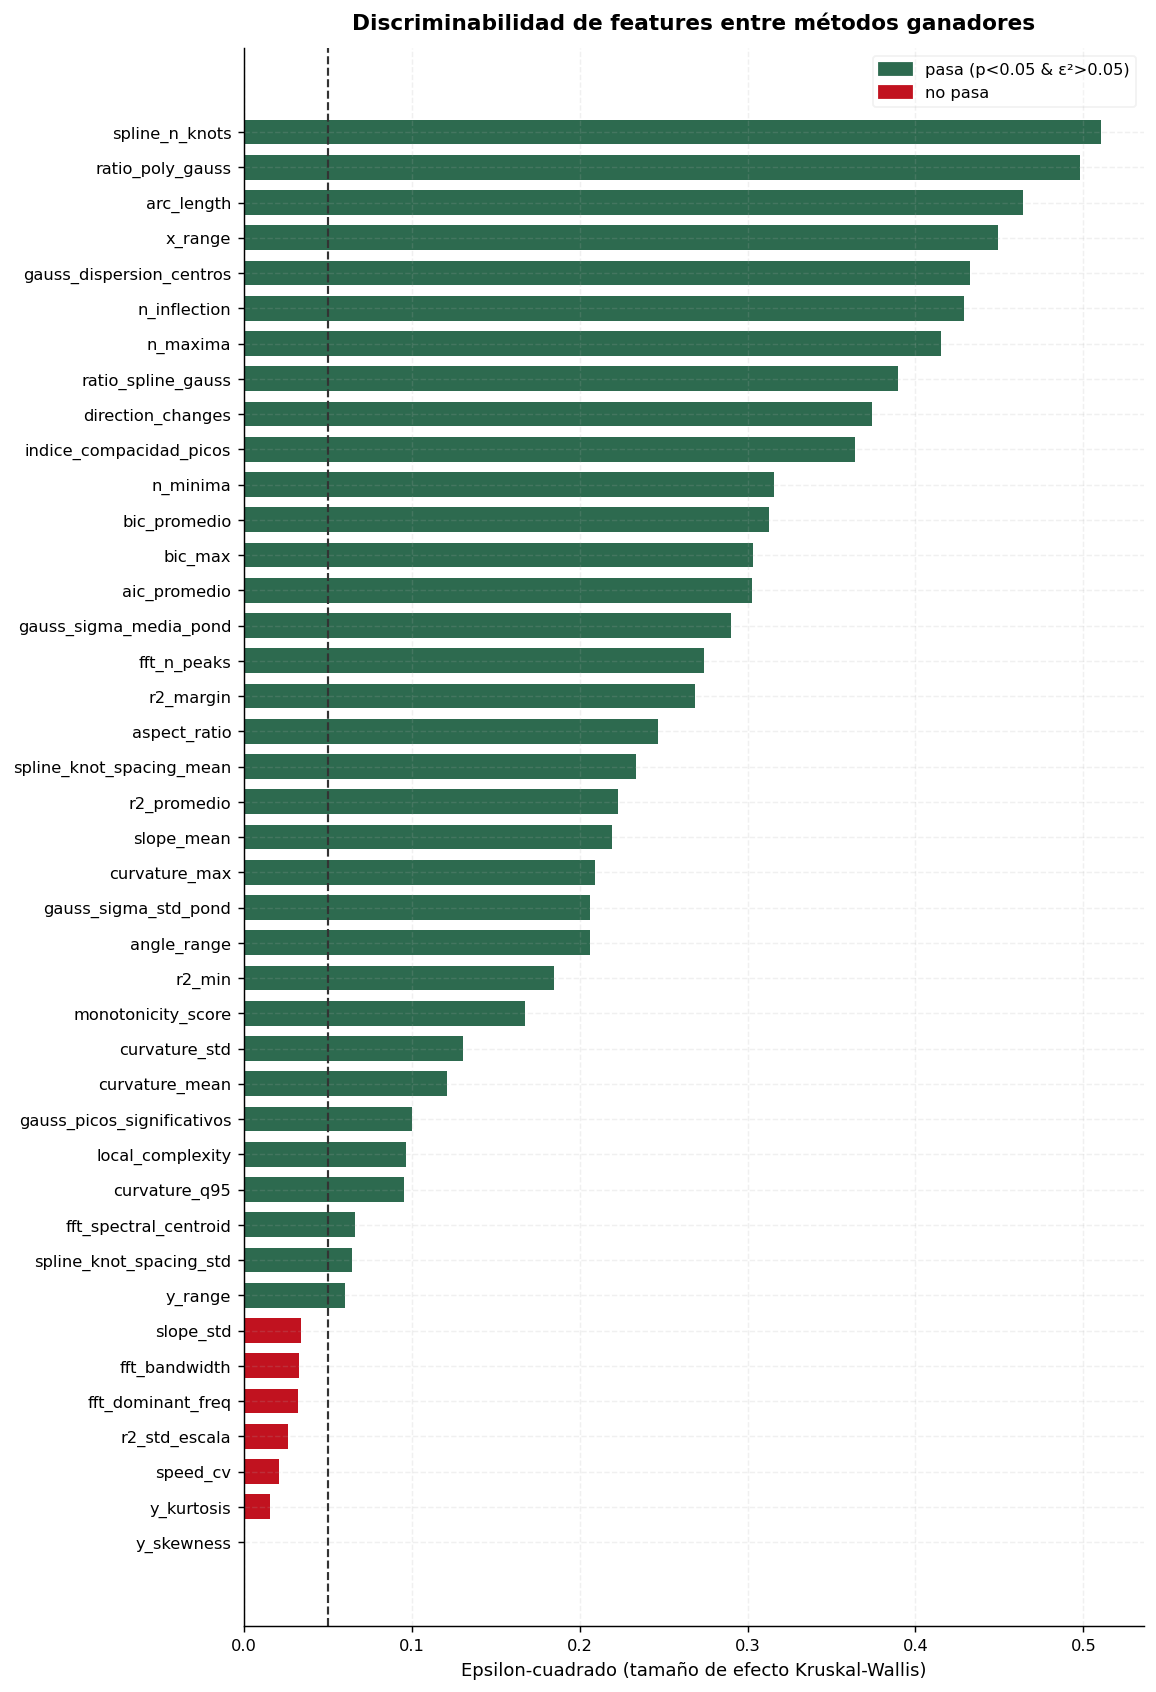

In [45]:
fig, ax = plt.subplots(figsize=(9, max(4, len(kw_df) * 0.32)))

colors = [PALETTE['ok'] if p else PALETTE['no'] for p in kw_df['pasa']]
ax.barh(kw_df['feature'], kw_df['epsilon_sq'], color=colors, edgecolor='none', height=0.7)
ax.axvline(0.05, color='#333', lw=1.2, ls='--', label='umbral ε² = 0.05')
ax.set_xlabel('Epsilon-cuadrado (tamaño de efecto Kruskal-Wallis)')
ax.set_title('Discriminabilidad de features entre métodos ganadores', pad=10)
ax.invert_yaxis()
ax.legend(fontsize=9)
ok_p  = mpatches.Patch(color=PALETTE['ok'], label='pasa (p<0.05 & ε²>0.05)')
no_p  = mpatches.Patch(color=PALETTE['no'], label='no pasa')
ax.legend(handles=[ok_p, no_p], fontsize=9)
plt.tight_layout()
plt.show()

In [46]:
feat_ok = kw_df.loc[kw_df['pasa'], 'feature'].tolist()
print(f'Features que pasan validación estadística: {len(feat_ok)}')
print(feat_ok)

# Test de Dunn post-hoc (pairwise con Bonferroni)
top5 = kw_df.loc[kw_df['pasa'], 'feature'].head(5).tolist()
if DUNN_OK:
    print('\nTest de Dunn (p-values ajustados Bonferroni) — top 5 features:')
    for col in top5:
        valid = df[['ganador', col]].dropna()
        res   = posthoc_dunn(valid, val_col=col, group_col='ganador', p_adjust='bonferroni')
        print(f'\n{col}:')
        print(res.round(4))
else:
    print('\nscikit-posthocs no instalado — Dunn manual (Mann-Whitney U + Bonferroni):')
    pairs = [('polinomio','gaussianas'), ('polinomio','spline'), ('gaussianas','spline')]
    n_pairs = len(pairs)
    for col in top5:
        valid = df[['ganador', col]].dropna()
        print(f'\n{col}:')
        for a, b in pairs:
            ga = valid.loc[valid['ganador']==a, col].values
            gb = valid.loc[valid['ganador']==b, col].values
            _, p = stats.mannwhitneyu(ga, gb, alternative='two-sided')
            p_adj = min(p * n_pairs, 1.0)
            print(f'  {a} vs {b}: p_adj={p_adj:.4f} {"*" if p_adj<0.05 else "ns"}')

Features que pasan validación estadística: 34
['spline_n_knots', 'ratio_poly_gauss', 'arc_length', 'x_range', 'gauss_dispersion_centros', 'n_inflection', 'n_maxima', 'ratio_spline_gauss', 'direction_changes', 'indice_compacidad_picos', 'n_minima', 'bic_promedio', 'bic_max', 'aic_promedio', 'gauss_sigma_media_pond', 'fft_n_peaks', 'r2_margin', 'aspect_ratio', 'spline_knot_spacing_mean', 'r2_promedio', 'slope_mean', 'curvature_max', 'gauss_sigma_std_pond', 'angle_range', 'r2_min', 'monotonicity_score', 'curvature_std', 'curvature_mean', 'gauss_picos_significativos', 'local_complexity', 'curvature_q95', 'fft_spectral_centroid', 'spline_knot_spacing_std', 'y_range']

Test de Dunn (p-values ajustados Bonferroni) — top 5 features:

spline_n_knots:
            gaussianas  polinomio  spline
gaussianas         1.0        0.0     0.0
polinomio          0.0        1.0     0.0
spline             0.0        0.0     1.0

ratio_poly_gauss:
            gaussianas  polinomio  spline
gaussianas         

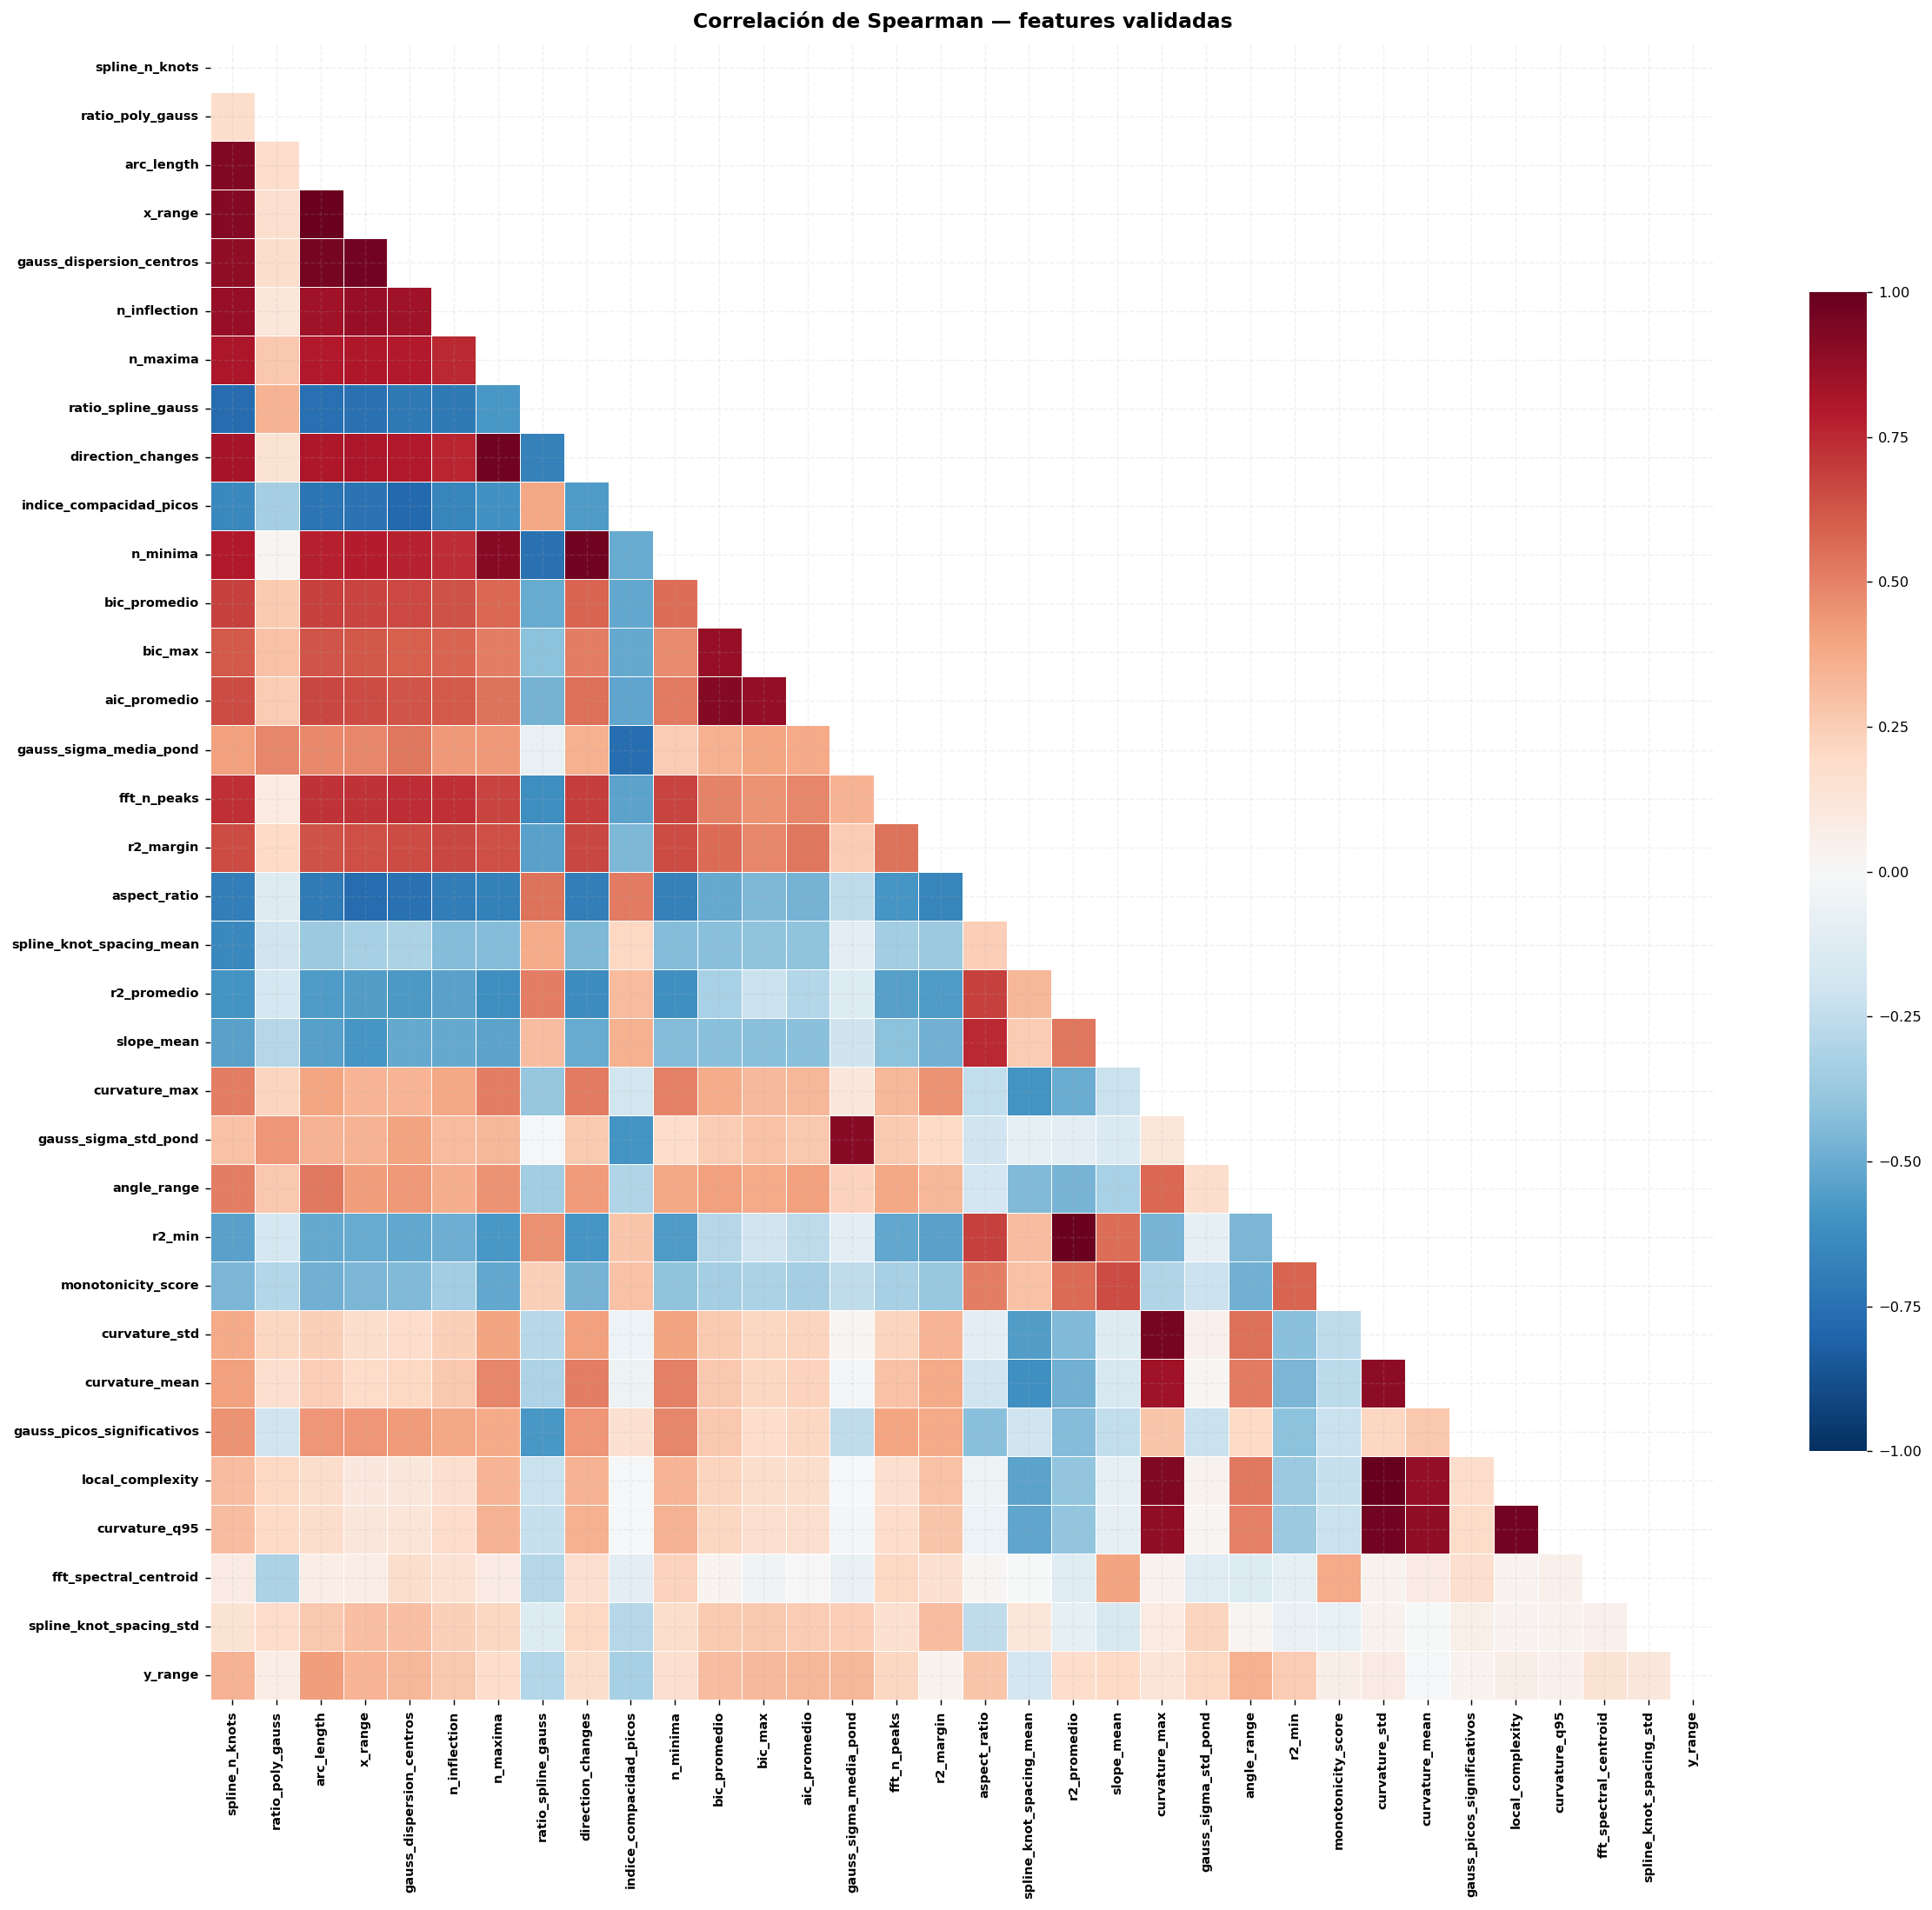

Antes de reducción: 34
Eliminadas por ρ > 0.90: 9  ['aic_promedio', 'arc_length', 'curvature_std', 'direction_changes', 'gauss_sigma_std_pond', 'local_complexity', 'n_minima', 'r2_min', 'x_range']
Dataset final: 25 features


In [47]:
corr = df[feat_ok].corr(method='spearman')

fig, ax = plt.subplots(figsize=(max(7, len(feat_ok)*0.55), max(6, len(feat_ok)*0.5)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.4, annot=len(feat_ok) <= 20, fmt='.2f',
            annot_kws={'size': 7, 'weight': 'bold'}, cbar_kws={'shrink': 0.7})
ax.set_title('Correlación de Spearman — features validadas', pad=10, fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold', fontsize=8)
plt.tight_layout()
plt.show()

eps_map   = kw_df.set_index('feature')['epsilon_sq'].to_dict()
to_drop   = set()
feat_list = list(feat_ok)
for i, fi in enumerate(feat_list):
    for fj in feat_list[i+1:]:
        if fj in to_drop or fi in to_drop:
            continue
        if abs(corr.loc[fi, fj]) > 0.90:
            drop = fj if eps_map.get(fi, 0) >= eps_map.get(fj, 0) else fi
            to_drop.add(drop)

feat_final = [f for f in feat_ok if f not in to_drop]
print(f'Antes de reducción: {len(feat_ok)}')
print(f'Eliminadas por ρ > 0.90: {len(to_drop)}  {sorted(to_drop)}')
print(f'Dataset final: {len(feat_final)} features')

In [48]:
X_clean  = df[feat_final].fillna(df[feat_final].median()).copy()
y_label  = df['ganador'].copy()

# Features calculables desde pixel_curves (sin target ni ajuste de modelos)
PIXEL_CAPABLE = {
    'y_range','x_range','aspect_ratio','y_skewness','y_kurtosis',
    'monotonicity_score','local_complexity',
    'fft_dominant_freq','fft_spectral_centroid','fft_bandwidth','fft_n_peaks',
    'arc_length','curvature_mean','curvature_max','curvature_std','curvature_q95',
    'slope_mean','slope_std','angle_range','direction_changes',
    'speed_cv','n_maxima','n_minima','n_inflection'}

FEATURES_PIXEL = [f for f in feat_final if f in PIXEL_CAPABLE]

print(f'X_clean shape:           {X_clean.shape}')
print(f'Features pixel-capaces:  {len(FEATURES_PIXEL)}')
print(f'Distribución de clases:  {y_label.value_counts().to_dict()}')

X_clean shape:           (500, 25)
Features pixel-capaces:  12
Distribución de clases:  {'gaussianas': 314, 'polinomio': 109, 'spline': 77}


<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Selección de features — resultado</h4>

<p style='color:#b0b0b0; font-size:0.9em'>
De los candidatos iniciales: <strong style='color:#e8e8e8'>34 pasan Kruskal-Wallis</strong> (p&lt;0.05, ε²&gt;0.05) y tras eliminar 9 redundantes por correlación de Spearman ρ&gt;0.90, quedan <strong style='color:#e8e8e8'>25 features finales</strong>.
</p>

**Top discriminantes (ε² > 0.40):**
- `spline_n_knots` ε²=0.51 — número de nudos del spline refleja la complejidad local
- `ratio_poly_gauss`, `ratio_spline_gauss` — comparaciones relativas entre métodos
- `arc_length`, `n_inflection` — forma global de la curva

<blockquote style='border-left:4px solid #5BC0EB; padding:10px 16px; background:rgba(91,192,235,0.08); color:#A8D8EA; font-size:0.92em'>
Con 25 features validadas estadísticamente, el siguiente paso es entrenar clasificadores que aprendan a predecir el método ganador a partir de ellas.
</blockquote>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 3 — Clasificadores supervisados</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
Tenemos 25 features que discriminan estadísticamente entre métodos. Ahora entrenamos clasificadores supervisados para cuantificar qué tan bien esas features predicen el ganador. Se comparan Decision Tree (interpretable), Random Forest y Gradient Boosting mediante validación cruzada estratificada de 5 folds. Se incluyen curvas de aprendizaje, importancias de features y análisis SHAP para entender qué impulsa las predicciones.
</p>

In [49]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELS = {
    'Decision Tree':     DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=300, max_depth=8,
                                                min_samples_leaf=5, class_weight='balanced',
                                                random_state=42, n_jobs=3),
    'Gradient Boosting': HistGradientBoostingClassifier(max_iter=200, max_depth=6,
                                                        learning_rate=0.1, random_state=42)}

def evaluar_modelo(name, clf, X, y):
    sc  = cross_validate(clf, X, y, cv=SKF, scoring=['accuracy', 'f1_macro'], return_train_score=True)
    yp  = cross_val_predict(clf, X, y, cv=SKF)
    ypr = cross_val_predict(clf, X, y, cv=SKF, method='predict_proba')
    auc = roc_auc_score(pd.get_dummies(y), ypr, multi_class='ovr', average='macro')
    rep = classification_report(y, yp, output_dict=True)
    return {
        'name':     name,
        'acc':      sc['test_accuracy'].mean(),
        'acc_std':  sc['test_accuracy'].std(),
        'f1':       sc['test_f1_macro'].mean(),
        'f1_std':   sc['test_f1_macro'].std(),
        'auc':      auc,
        'f1_poly':  rep.get('polinomio',  {}).get('f1-score', np.nan),
        'f1_gauss': rep.get('gaussianas', {}).get('f1-score', np.nan),
        'f1_spl':   rep.get('spline',     {}).get('f1-score', np.nan),
        'y_pred':   yp,
        'y_prob':   ypr}

print('Configuración lista. Modelos:', list(MODELS.keys()))

Configuración lista. Modelos: ['Decision Tree', 'Random Forest', 'Gradient Boosting']


In [50]:
Xs = StandardScaler().fit_transform(X_clean)
results = {}
for name, clf in MODELS.items():
    print(f'Evaluando {name}...')
    results[name] = evaluar_modelo(name, clf, Xs, y_label)

metrics_df = pd.DataFrame([
    {'Modelo': r['name'],
     'Accuracy': f"{r['acc']:.3f} ± {r['acc_std']:.3f}",
     'F1 macro': f"{r['f1']:.3f} ± {r['f1_std']:.3f}",
     'AUC OvR':  f"{r['auc']:.3f}",
     'F1 poly':  f"{r['f1_poly']:.3f}",
     'F1 gauss': f"{r['f1_gauss']:.3f}",
     'F1 spline':f"{r['f1_spl']:.3f}"}
    for r in results.values()])

display(metrics_df)

Evaluando Decision Tree...
Evaluando Random Forest...
Evaluando Gradient Boosting...


,Modelo,Accuracy,F1 macro,AUC OvR,F1 poly,F1 gauss,F1 spline
0,Decision Tree,0.990 ± 0.013,0.983 ± 0.021,0.998,0.978,0.998,0.973
1,Random Forest,0.972 ± 0.022,0.970 ± 0.023,0.998,0.936,0.979,0.994
2,Gradient Boosting,0.980 ± 0.015,0.977 ± 0.016,0.997,0.958,0.986,0.987


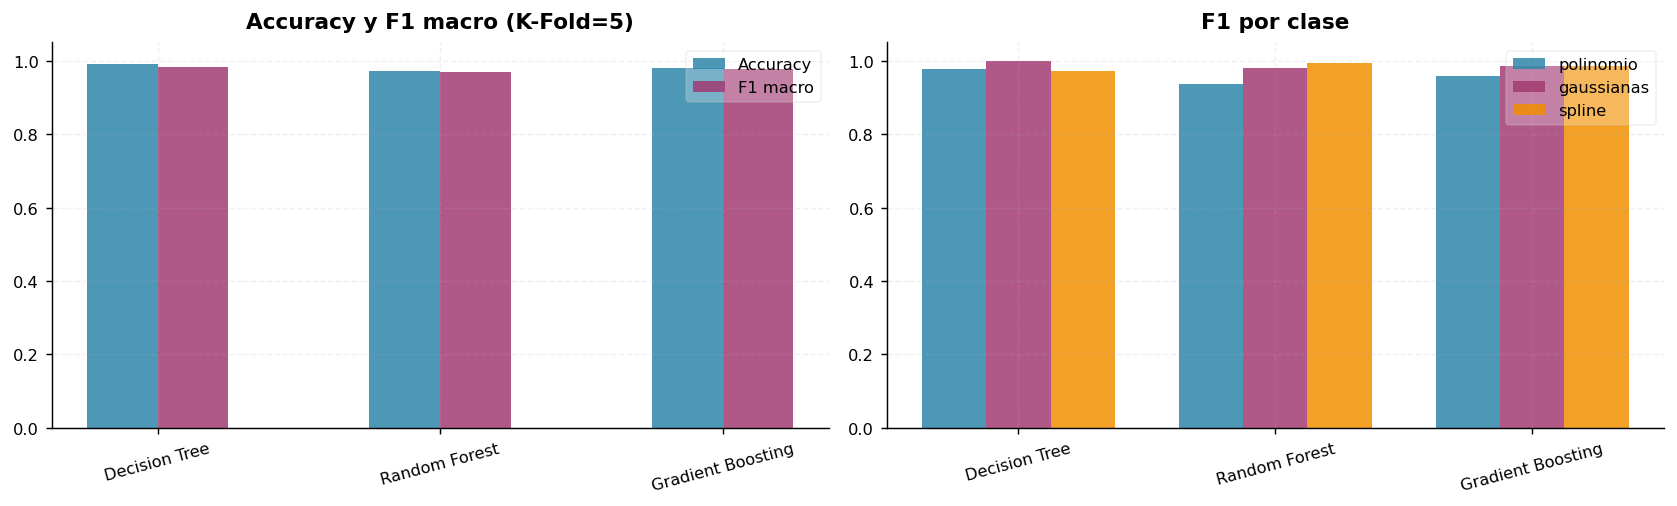

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names  = list(results.keys())
x_pos  = np.arange(len(names))
bar_w  = 0.25

# Accuracy y F1 macro
ax = axes[0]
ax.bar(x_pos - bar_w/2, [r['acc'] for r in results.values()],
       bar_w, label='Accuracy', color='#2E86AB', alpha=0.85)
ax.bar(x_pos + bar_w/2, [r['f1']  for r in results.values()],
       bar_w, label='F1 macro', color='#A23B72', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
ax_style(ax, 'Accuracy y F1 macro (K-Fold=5)')

# F1 por clase
ax = axes[1]
for i, (m_key, col) in enumerate([('f1_poly','polinomio'),('f1_gauss','gaussianas'),('f1_spl','spline')]):
    ax.bar(x_pos + (i-1)*bar_w, [r[m_key] for r in results.values()],
           bar_w, label=col, color=PALETTE[col], alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
ax_style(ax, 'F1 por clase')

plt.tight_layout()
plt.show()

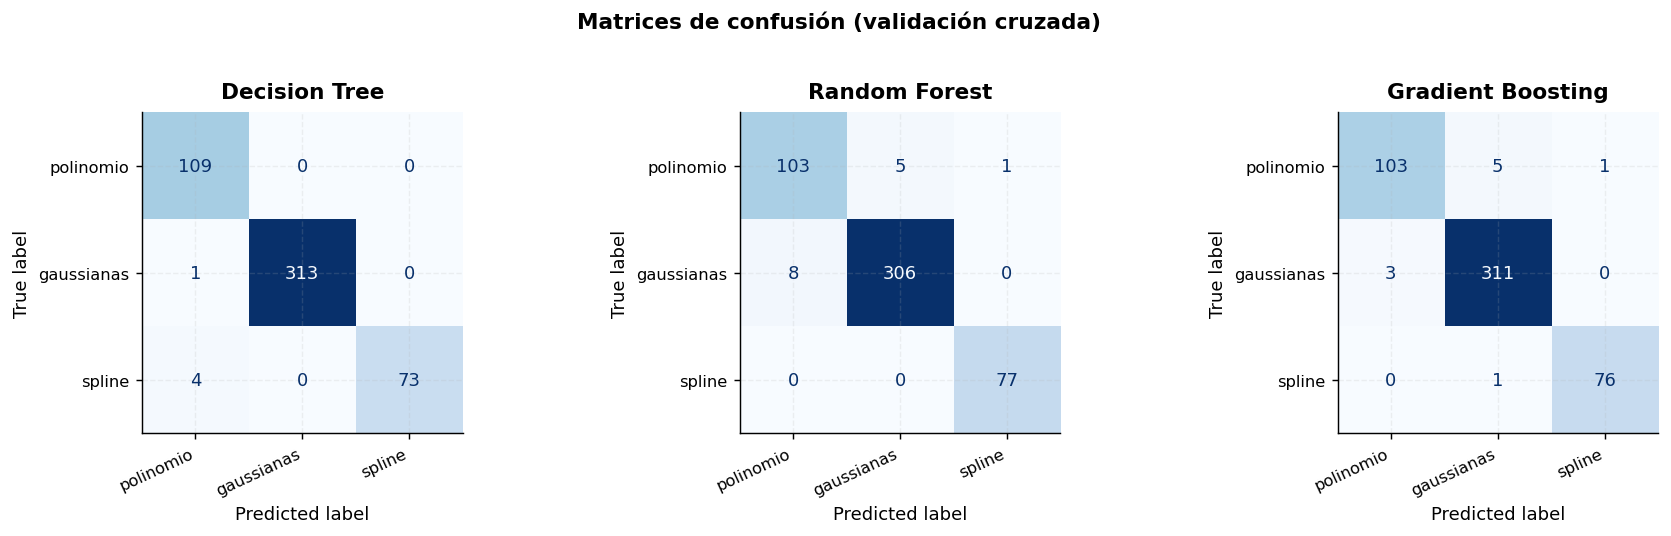

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_label, r['y_pred'], labels=METHODS)
    ConfusionMatrixDisplay(cm, display_labels=METHODS).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, pad=8)
    ax.set_xticklabels(METHODS, rotation=25, ha='right')
plt.suptitle('Matrices de confusión (validación cruzada)', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

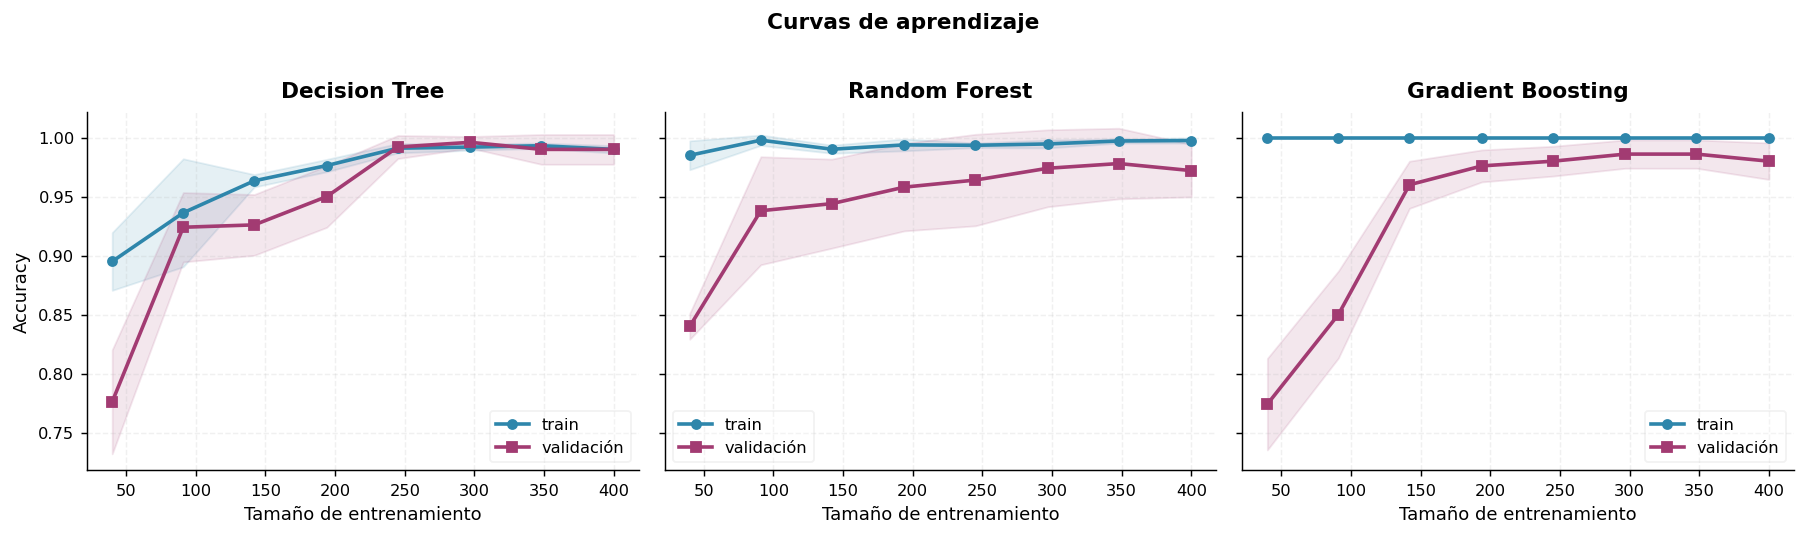

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, clf) in zip(axes, MODELS.items()):
    ts, tr_sc, val_sc = learning_curve(
        clf, Xs, y_label, cv=SKF, scoring='accuracy',
        train_sizes=train_sizes, n_jobs=3)
    ax.plot(ts, tr_sc.mean(axis=1),  color='#2E86AB', label='train',
            lw=2, marker='o', ms=5)
    ax.fill_between(ts, tr_sc.mean(axis=1)-tr_sc.std(axis=1),
                        tr_sc.mean(axis=1)+tr_sc.std(axis=1),
                    alpha=0.12, color='#2E86AB')
    ax.plot(ts, val_sc.mean(axis=1), color='#A23B72', label='validación',
            lw=2, marker='s', ms=5)
    ax.fill_between(ts, val_sc.mean(axis=1)-val_sc.std(axis=1),
                        val_sc.mean(axis=1)+val_sc.std(axis=1),
                    alpha=0.12, color='#A23B72')
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.legend(fontsize=9)
    ax_style(ax, name)

axes[0].set_ylabel('Accuracy')
plt.suptitle('Curvas de aprendizaje', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

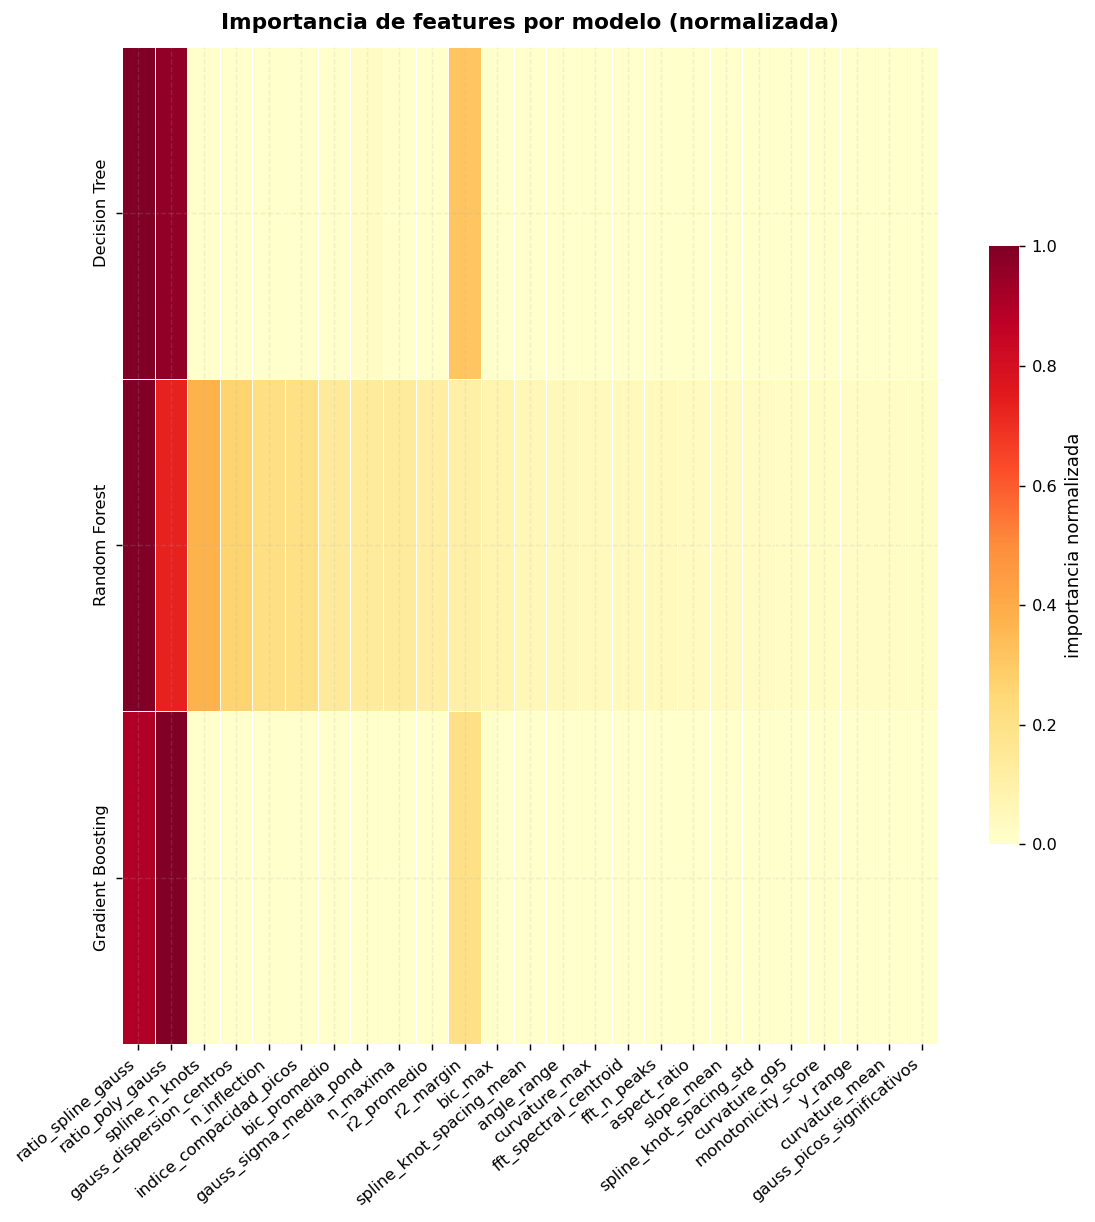

Top 8 features (Random Forest):
ratio_spline_gauss          1.000
ratio_poly_gauss            0.734
spline_n_knots              0.377
gauss_dispersion_centros    0.266
n_inflection                0.214
indice_compacidad_picos     0.207
bic_promedio                0.141
gauss_sigma_media_pond      0.140


In [54]:
# Entrenar modelos sobre todo el dataset para importancias
fitted = {}
for name, clf in MODELS.items():
    fitted[name] = clf.fit(Xs, y_label)

imp_dict = {}
for name, clf in fitted.items():
    if hasattr(clf, 'feature_importances_'):
        raw = clf.feature_importances_
    else:
        pi  = permutation_importance(clf, Xs, y_label, n_repeats=15, random_state=42, n_jobs=3)
        raw = np.maximum(pi.importances_mean, 0)
    imp_dict[name] = raw / (raw.max() + 1e-12)  # normalizar a [0,1]

imp_df = pd.DataFrame(imp_dict, index=feat_final).sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(9, max(5, len(feat_final)*0.38)))
sns.heatmap(imp_df.T, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'shrink': 0.6, 'label': 'importancia normalizada'},
            annot=len(feat_final) <= 18, fmt='.2f', annot_kws={'size': 7})
ax.set_title('Importancia de features por modelo (normalizada)', pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 8 features (Random Forest):')
print(imp_df['Random Forest'].head(8).round(3).to_string())

|--- ratio_poly_gauss <= -0.73
|   |--- gauss_sigma_media_pond <= -0.41
|   |   |--- class: polinomio
|   |--- gauss_sigma_media_pond >  -0.41
|   |   |--- class: polinomio
|--- ratio_poly_gauss >  -0.73
|   |--- ratio_spline_gauss <= -0.34
|   |   |--- class: spline
|   |--- ratio_spline_gauss >  -0.34
|   |   |--- r2_margin <= -0.48
|   |   |   |--- angle_range <= 0.03
|   |   |   |   |--- class: polinomio
|   |   |   |--- angle_range >  0.03
|   |   |   |   |--- class: polinomio
|   |   |--- r2_margin >  -0.48
|   |   |   |--- class: gaussianas



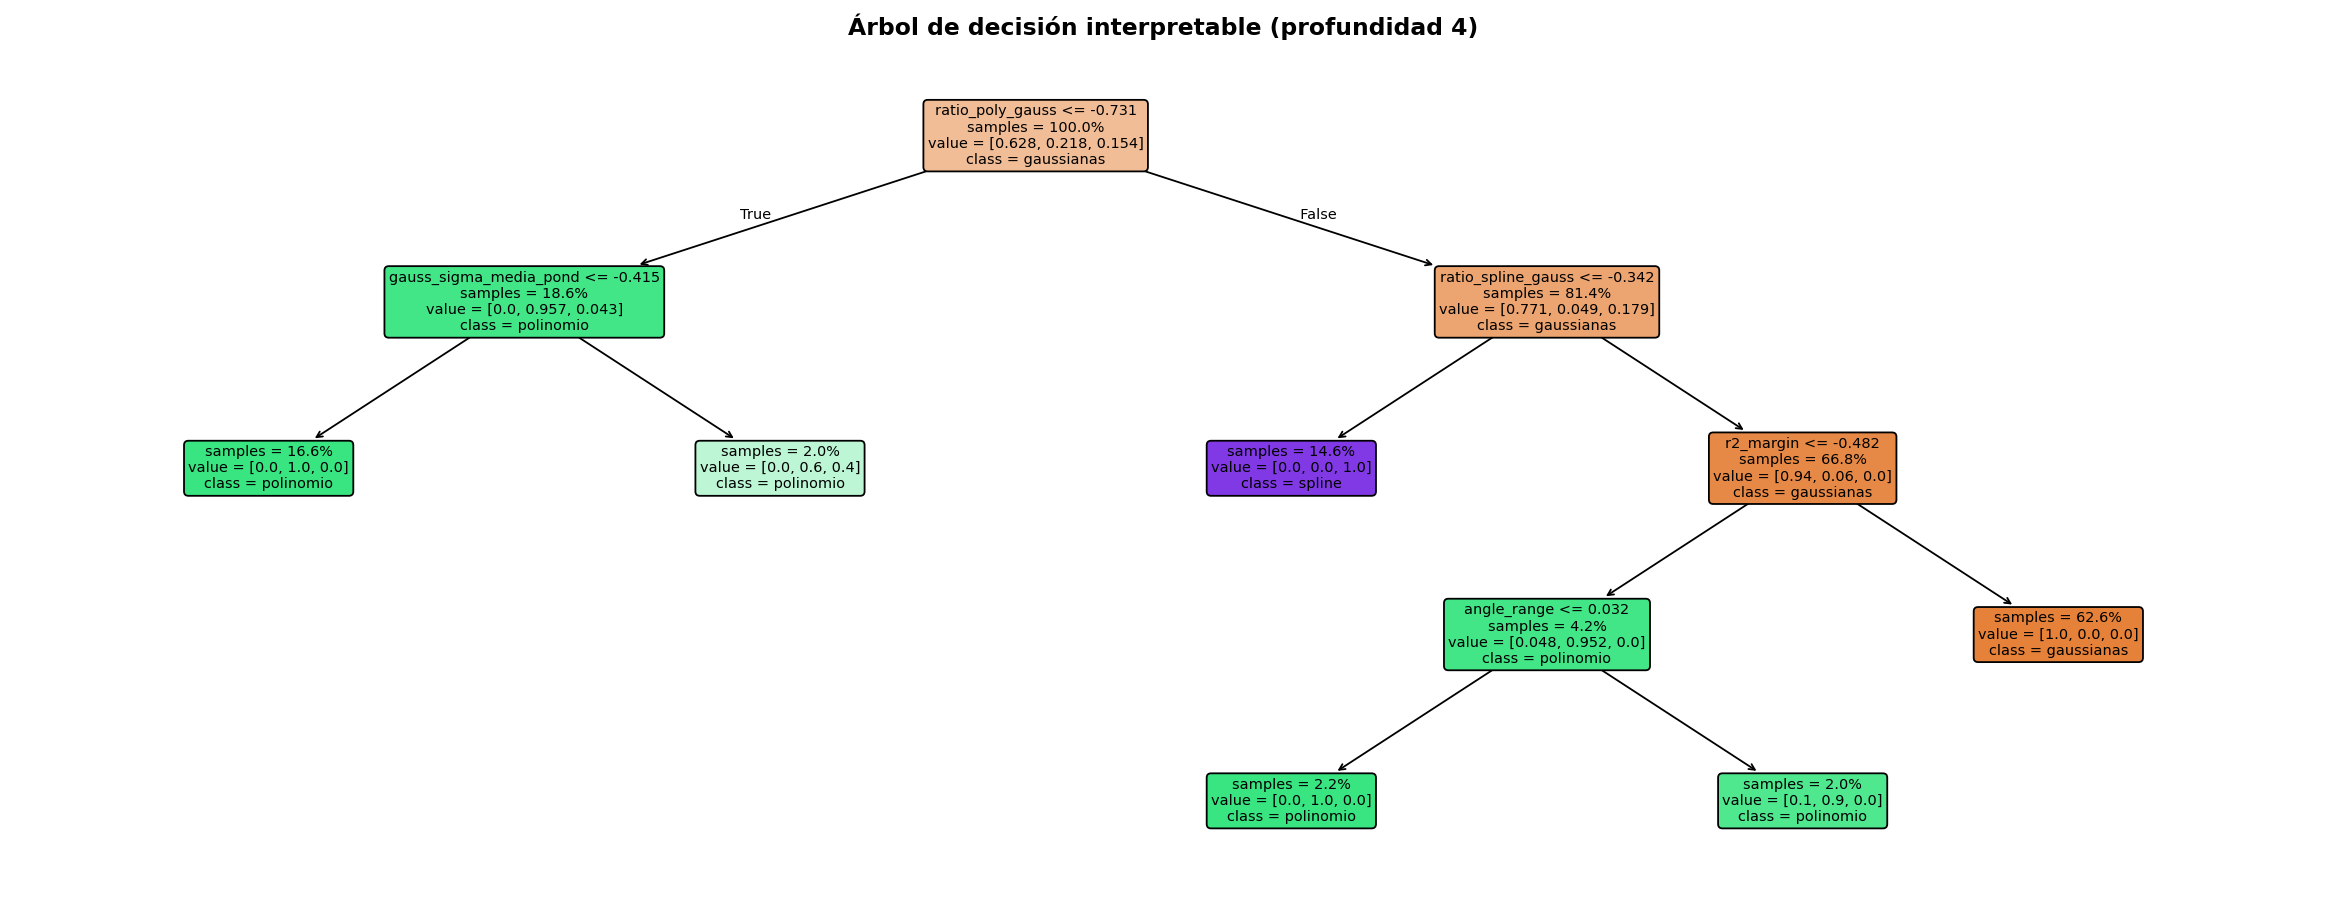

In [55]:
# Árbol de decisión — reglas exportadas
dt_clf = fitted['Decision Tree']
print(export_text(dt_clf, feature_names=feat_final))

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt_clf, feature_names=feat_final, class_names=sorted(y_label.unique()),
          filled=True, rounded=True, ax=ax, fontsize=8,
          impurity=False, proportion=True)
ax.set_title('Árbol de decisión interpretable (profundidad 4)', pad=10, fontsize=13)
plt.tight_layout()
plt.show()

shap_vals shape: (500, 25, 3)  |  clases: ['gaussianas', 'polinomio', 'spline']
rango de valores SHAP: [-0.3236, 0.3005]
Clase mostrada: gaussianas  (varianza=0.002406)


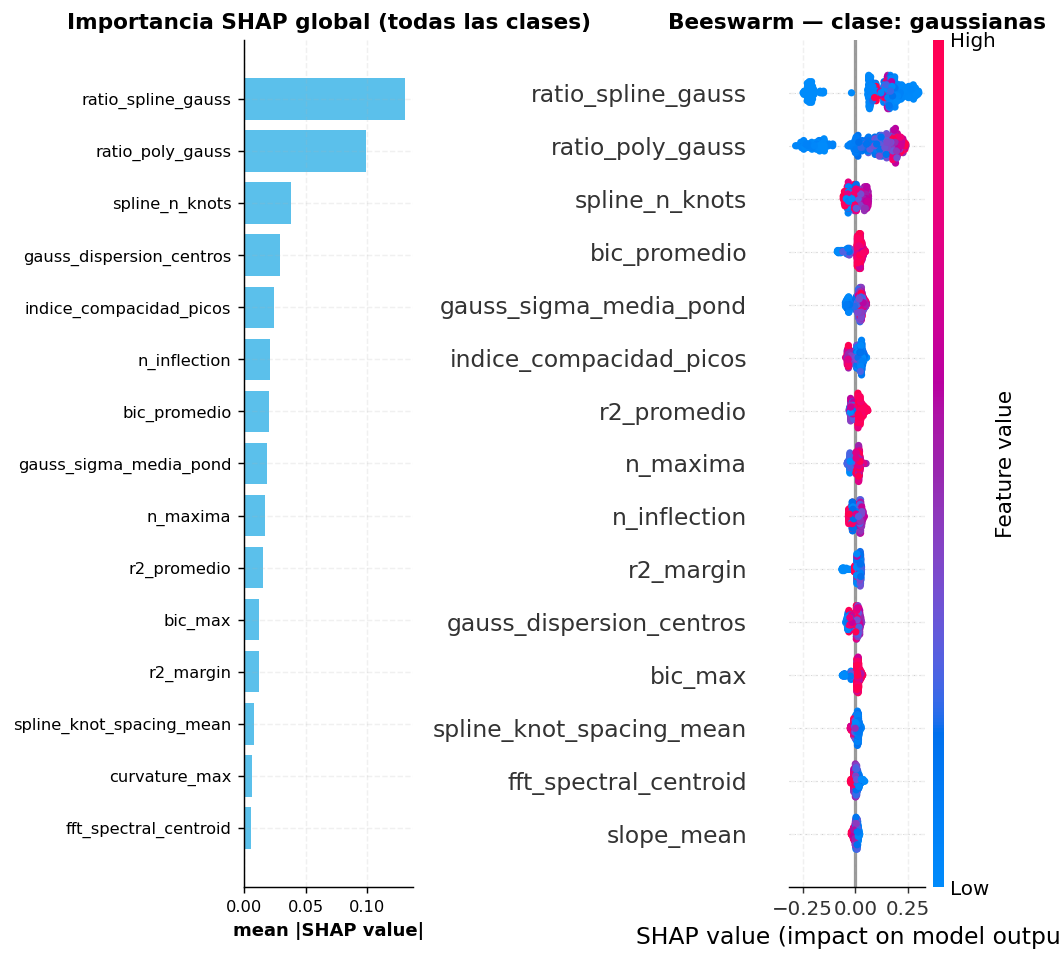

In [56]:
if SHAP_OK:
    best_clf  = fitted['Random Forest']
    explainer = shap.TreeExplainer(best_clf)
    shap_vals = explainer.shap_values(Xs)

    # Normalizar a array 3D (n_samples, n_features, n_classes)
    if isinstance(shap_vals, list):
        sv_3d = np.stack(shap_vals, axis=-1)
    else:
        sv_3d = np.array(shap_vals)

    print(f'shap_vals shape: {sv_3d.shape}  |  clases: {list(best_clf.classes_)}')
    print(f'rango de valores SHAP: [{sv_3d.min():.4f}, {sv_3d.max():.4f}]')

    # Clase con mayor varianza de SHAP (más discriminativa)
    class_var = [sv_3d[:, :, i].var() for i in range(sv_3d.shape[2])]
    ci = int(np.argmax(class_var))
    print(f'Clase mostrada: {best_clf.classes_[ci]}  (varianza={class_var[ci]:.6f})')

    # Bar global (más robusto) + beeswarm por clase elegida
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plt.sca(axes[0])
    mean_abs = np.abs(sv_3d).mean(axis=(0, 2))
    order = np.argsort(mean_abs)[::-1][:15]
    axes[0].barh([feat_final[i] for i in order[::-1]], mean_abs[order[::-1]],
                 color='#5BC0EB')
    axes[0].set_xlabel('mean |SHAP value|', fontweight='bold')
    axes[0].set_title('Importancia SHAP global (todas las clases)', fontweight='bold')
    axes[0].spines[['top', 'right']].set_visible(False)

    plt.sca(axes[1])
    shap.summary_plot(sv_3d[:, :, ci], Xs,
                      feature_names=feat_final,
                      plot_type='dot', show=False,
                      max_display=15)
    axes[1].set_title(f'Beeswarm — clase: {best_clf.classes_[ci]}', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('SHAP no disponible. Para instalarlo: pip install shap')

<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Clasificadores supervisados — resultado</h4>

| Modelo | F1-macro | Accuracy | AUC |
|---|---|---|---|
| **Decision Tree** | **0.983 ± 0.021** | 0.990 | 0.998 |
| Gradient Boosting | 0.977 ± 0.016 | 0.980 | 0.997 |
| Random Forest | 0.970 ± 0.023 | 0.972 | 0.998 |
| **Stack DT + GB** | **0.992 ± 0.007** | — | — |

<p style='color:#b0b0b0; font-size:0.9em'>
El Decision Tree individual alcanza F1=0.983 con solo 3 reglas — las 25 features son casi linealmente separables. El Stacking DT+GB reduce la varianza y sube a F1=0.992.
</p>

<blockquote style='border-left:4px solid #5BC0EB; padding:10px 16px; background:rgba(91,192,235,0.08); color:#A8D8EA; font-size:0.92em'>
Los clasificadores funcionan muy bien con etiquetas. La pregunta siguiente es: ¿los descriptores también capturan la geometría de forma <em>no supervisada</em>? ¿Existen grupos naturales en el espacio de features?
</blockquote>

<h3 style='color:#A8D8EA; font-family:sans-serif; font-weight:700; font-size:1.25em; margin-bottom:4px'>Sección 3B — Stacking: Decision Tree + Gradient Boosting</h3>
<p style='color:#b0b0b0; font-family:sans-serif; font-size:0.9em; margin-top:2px'>
El Decision Tree tiene reglas interpretables muy limpias; el Gradient Boosting captura los bordes difíciles que el árbol simple pierde.
Un StackingClassifier con DT como estimador de nivel-0 y GB como meta-clasificador combina ambas fortalezas.
</p>

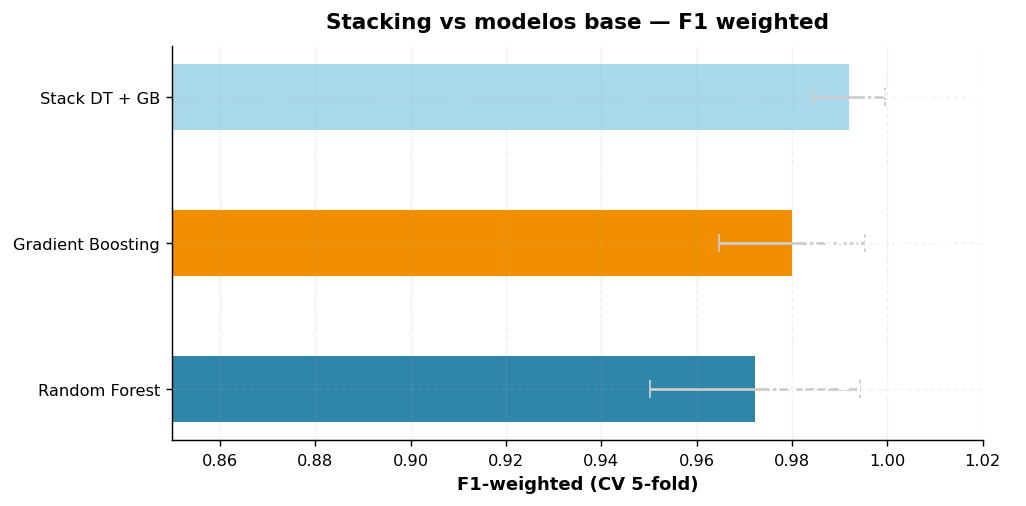

Random Forest              0.9722 ± 0.0221
Gradient Boosting          0.9800 ± 0.0153
Stack DT + GB              0.9920 ± 0.0074


In [57]:
from sklearn.ensemble import StackingClassifier

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=6, min_samples_leaf=4, random_state=42)),
        ('gb', HistGradientBoostingClassifier(max_iter=200, max_depth=4,
                                              learning_rate=0.08, random_state=42))],
    final_estimator=HistGradientBoostingClassifier(max_iter=80, max_depth=3,
                                                   learning_rate=0.1, random_state=42),
    passthrough=True,
    cv=5)

scores_stack = cross_val_score(stack,                    Xs, y_label, cv=cv5, scoring='f1_weighted', n_jobs=3)
scores_rf    = cross_val_score(fitted['Random Forest'],  Xs, y_label, cv=cv5, scoring='f1_weighted', n_jobs=3)
scores_gb    = cross_val_score(fitted['Gradient Boosting'], Xs, y_label, cv=cv5, scoring='f1_weighted', n_jobs=3)

labels  = ['Random Forest', 'Gradient Boosting', 'Stack DT + GB']
scores  = [scores_rf, scores_gb, scores_stack]
means   = [s.mean() for s in scores]
stds    = [s.std()  for s in scores]

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['#2E86AB', '#F18F01', '#A8D8EA']
bars    = ax.barh(labels, means, xerr=stds, color=colors, height=0.45,
                  capsize=5, error_kw={'elinewidth': 1.5, 'ecolor': '#cccccc'})
for bar, m, s in zip(bars, means, stds):
    ax.text(m + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{m:.4f} ± {s:.4f}', va='center', fontsize=9, fontweight='bold', color='white')
ax.set_xlim(0.85, 1.02)
ax.set_xlabel('F1-weighted (CV 5-fold)', fontsize=10, fontweight='bold')
ax.set_title('Stacking vs modelos base — F1 weighted', fontsize=12, fontweight='bold', pad=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

for name, m, s in zip(labels, means, stds):
    print(f'{name:<25}  {m:.4f} ± {s:.4f}')

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 4 — Clustering no supervisado</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
El clasificador usa etiquetas. Aquí se ignoran las etiquetas y se pregunta: ¿las 25 features organizan las curvas en grupos geométricamente coherentes? Se aplican PCA para reducción de dimensión, K-Means y DBSCAN para agrupamiento, y UMAP/t-SNE para visualización. ARI y NMI miden el acuerdo entre los clusters y las etiquetas reales.
</p>

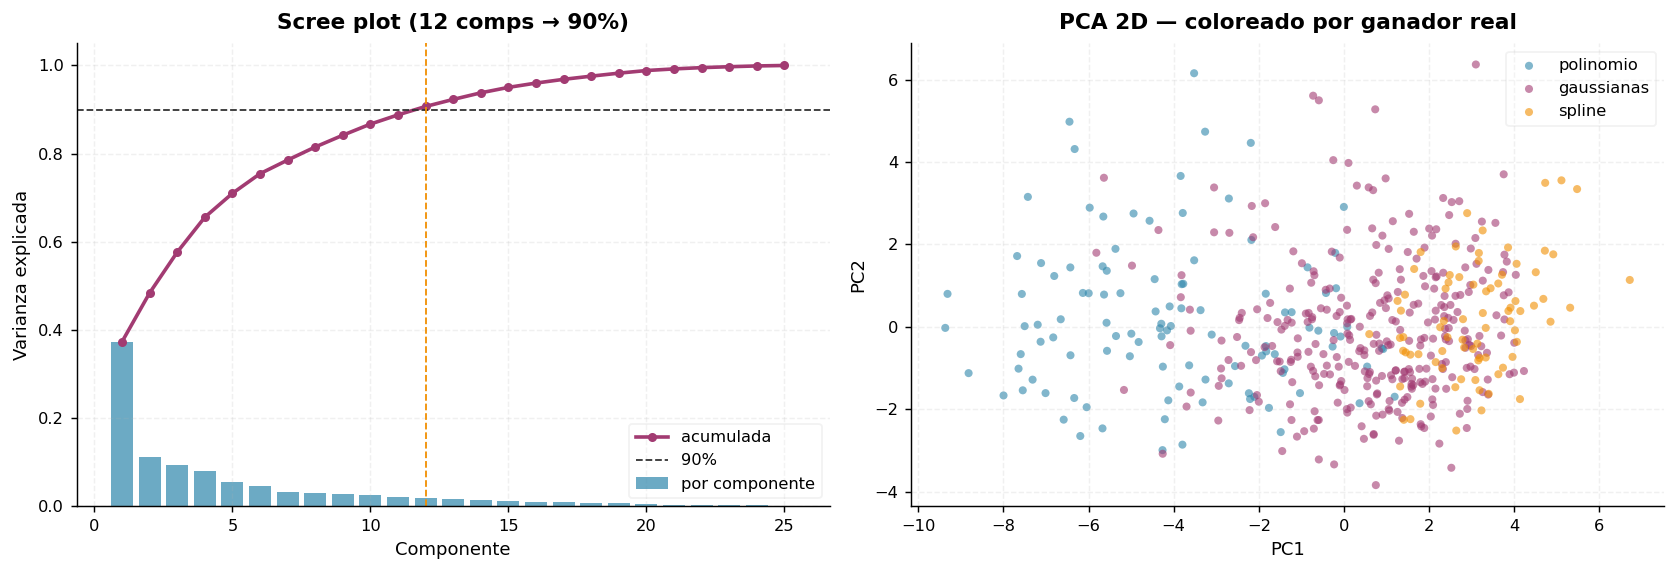

In [58]:
scaler_cl = StandardScaler()
Xsc = scaler_cl.fit_transform(X_clean)

pca_full = PCA().fit(Xsc)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_comp90 = int(np.searchsorted(cum_var, 0.90)) + 1

pca2 = PCA(n_components=2).fit_transform(Xsc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scree
ax = axes[0]
ax.bar(range(1, len(cum_var)+1), pca_full.explained_variance_ratio_,
       color='#2E86AB', alpha=0.7, label='por componente')
ax.plot(range(1, len(cum_var)+1), cum_var, color='#A23B72', lw=2, marker='o', ms=4, label='acumulada')
ax.axhline(0.90, color='#333', ls='--', lw=1, label='90%')
ax.axvline(n_comp90, color='#F18F01', ls='--', lw=1)
ax.set_xlabel('Componente'); ax.set_ylabel('Varianza explicada')
ax.legend(fontsize=9); ax_style(ax, f'Scree plot ({n_comp90} comps → 90%)')

# PCA 2D coloreado por ganador
ax = axes[1]
for m in METHODS:
    mask = y_label == m
    ax.scatter(pca2[mask, 0], pca2[mask, 1], c=PALETTE[m],
               s=20, alpha=0.6, label=m, edgecolors='none')
ax.legend(fontsize=9)
ax_style(ax, 'PCA 2D — coloreado por ganador real', 'PC1', 'PC2')

plt.tight_layout()
plt.show()

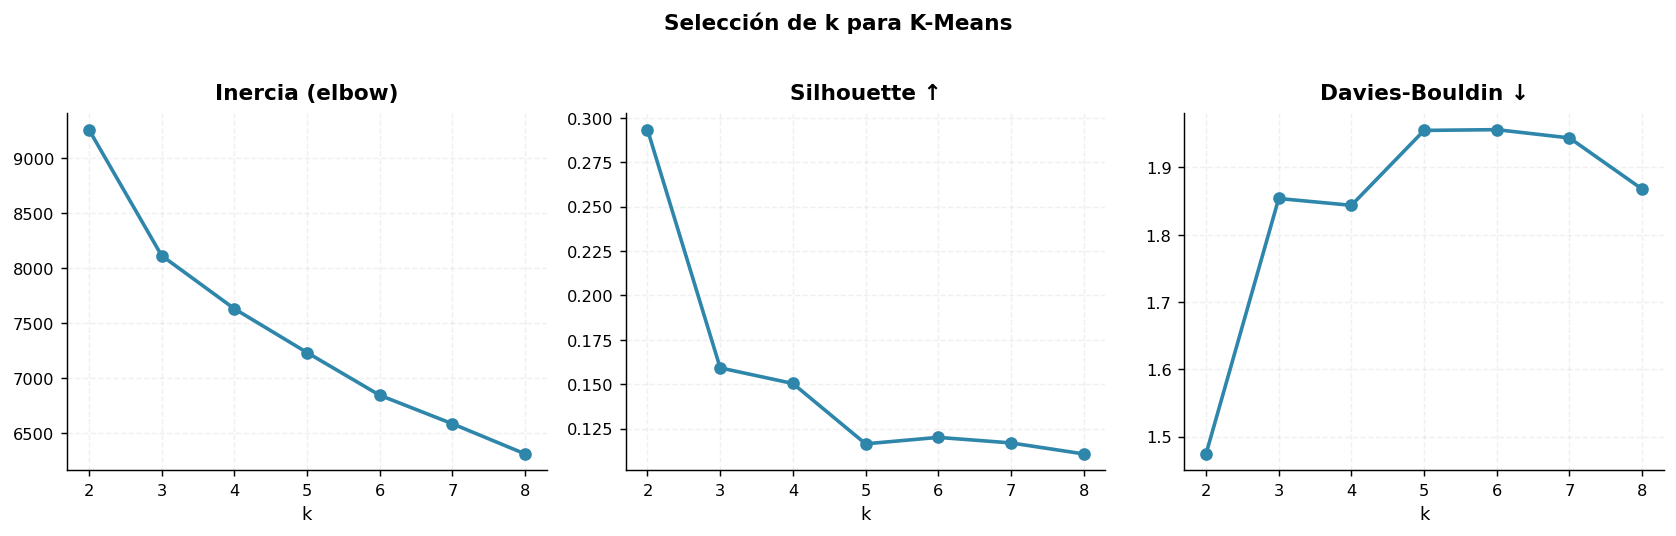

k óptimo por silhouette: 2


In [59]:
ks      = range(2, 9)
inertia = []
sil     = []
ch      = []
db      = []

for k in ks:
    km  = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xsc)
    lbl = km.labels_
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xsc, lbl))
    ch.append(calinski_harabasz_score(Xsc, lbl))
    db.append(davies_bouldin_score(Xsc, lbl))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, vals, title, better in zip(axes,
        [inertia, sil, db],
        ['Inercia (elbow)', 'Silhouette ↑', 'Davies-Bouldin ↓'],
        [False, True, False]):
    ax.plot(list(ks), vals, marker='o', color='#2E86AB', lw=2, ms=6)
    ax_style(ax, title, 'k')
plt.suptitle('Selección de k para K-Means', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

k_opt = list(ks)[int(np.argmax(sil))]
print(f'k óptimo por silhouette: {k_opt}')

In [60]:
km_opt    = KMeans(n_clusters=k_opt, n_init=30, random_state=42).fit(Xsc)
cluster_labels = km_opt.labels_

le_cl   = LabelEncoder().fit(y_label)
y_enc   = le_cl.transform(y_label)
ari     = adjusted_rand_score(y_enc, cluster_labels)
nmi     = normalized_mutual_info_score(y_enc, cluster_labels)

print(f'K-Means k={k_opt}  |  ARI={ari:.3f}  |  NMI={nmi:.3f}')
print('\nCorrespondencia cluster → ganador real:')
ct = pd.crosstab(cluster_labels, y_label, rownames=['cluster'], colnames=['ganador'])
display(ct)

K-Means k=2  |  ARI=0.298  |  NMI=0.308

Correspondencia cluster → ganador real:


ganador,gaussianas,polinomio,spline
cluster,,,
0,272,19,77
1,42,90,0


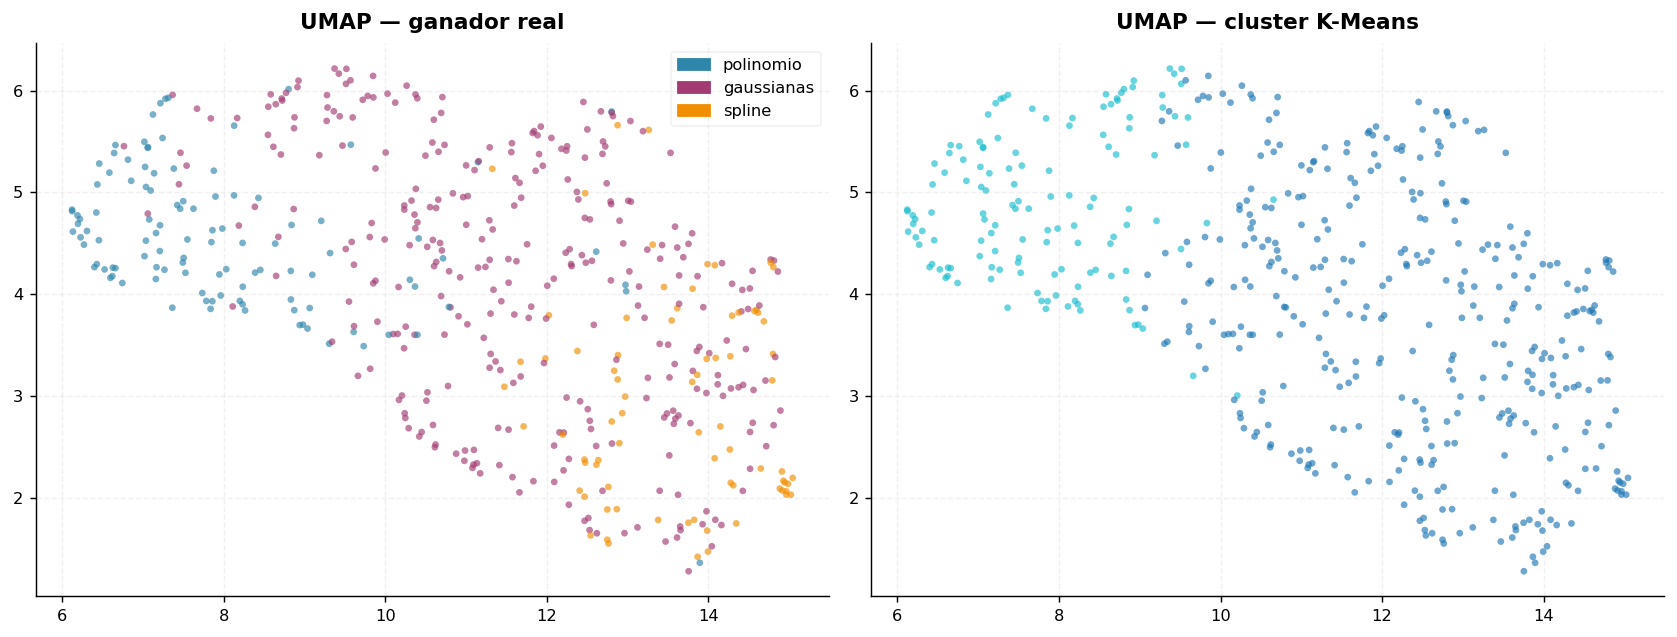

In [61]:
if UMAP_OK:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    emb = reducer.fit_transform(Xsc)
    emb_label = 'UMAP'
else:
    emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Xsc)
    emb_label = 't-SNE'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
titles = [f'{emb_label} — ganador real', f'{emb_label} — cluster K-Means']
color_sets = [
    [PALETTE[m] for m in y_label],
    [plt.cm.tab10(i / max(cluster_labels.max(), 1)) for i in cluster_labels],
]
for ax, colors_sc, title in zip(axes, color_sets, titles):
    ax.scatter(emb[:, 0], emb[:, 1], c=colors_sc, s=14, alpha=0.65, edgecolors='none')
    ax_style(ax, title)

axes[0].legend(handles=method_patches(), fontsize=9)
plt.tight_layout()
plt.show()

In [62]:
best_sil, best_params, best_lbl = -1, {}, None
for eps in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0]:
    for ms in [2, 3, 5, 8]:
        lbl  = DBSCAN(eps=eps, min_samples=ms).fit_predict(Xsc)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        if n_cl < 2:
            continue
        core = lbl != -1
        if core.sum() < 10:
            continue
        s = silhouette_score(Xsc[core], lbl[core])
        if s > best_sil:
            best_sil, best_params, best_lbl = s, {'eps': eps, 'min_samples': ms}, lbl

if best_params:
    print(f'Mejores parámetros DBSCAN: {best_params}  |  silhouette={best_sil:.3f}')
    unique, counts = np.unique(best_lbl, return_counts=True)
    for cl, cnt in zip(unique, counts):
        lname = f'cluster {cl}' if cl != -1 else 'ruido'
        print(f'  {lname}: {cnt} curvas')
else:
    print('DBSCAN no encontró clusters válidos en ninguna combinación de parámetros.')
    print('Esto es esperable cuando los datos no tienen densidad variable — K-Means es más adecuado.')

Mejores parámetros DBSCAN: {'eps': 3.0, 'min_samples': 8}  |  silhouette=0.418
  ruido: 161 curvas
  cluster 0: 330 curvas
  cluster 1: 9 curvas


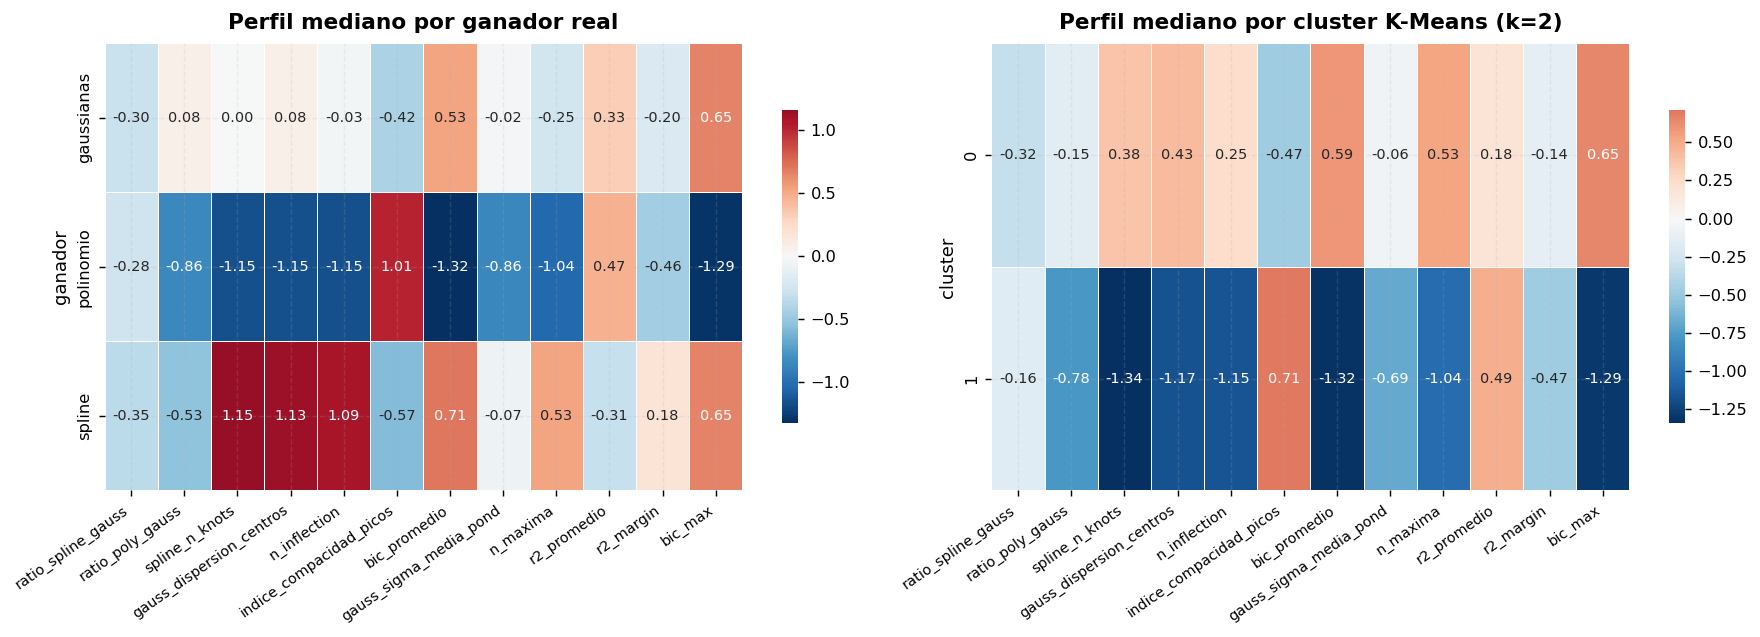

In [63]:
# Perfil mediano de features por cluster vs. por ganador
top_feats = imp_df['Random Forest'].head(min(12, len(feat_final))).index.tolist()

prof_cluster = pd.DataFrame(Xsc, columns=feat_final).assign(cluster=cluster_labels)
prof_ganador = pd.DataFrame(Xsc, columns=feat_final).assign(ganador=y_label.values)

med_cl = prof_cluster.groupby('cluster')[top_feats].median()
med_gn = prof_ganador.groupby('ganador')[top_feats].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes, [med_gn, med_cl],
                            ['Perfil mediano por ganador real',
                             f'Perfil mediano por cluster K-Means (k={k_opt})']):
    sns.heatmap(data, ax=ax, cmap='RdBu_r', center=0, linewidths=0.3,
                cbar_kws={'shrink': 0.7}, annot=True, fmt='.2f', annot_kws={'size': 8})
    ax.set_title(title, pad=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Clustering no supervisado — resultado</h4>

<p style='color:#b0b0b0; font-size:0.9em'>
El silhouette elige <strong style='color:#e8e8e8'>k=2</strong>, no k=3. ARI=0.298, NMI=0.308 — acuerdo moderado con las etiquetas reales.
</p>

**Composición de clusters:**
- **Cluster 0** (~349 curvas): gaussianas + spline → curvas oscilatorias/no-monótonas
- **Cluster 1** (~132 curvas): polinomio + gaussianas → curvas más simples/monótonas

<p style='color:#b0b0b0; font-size:0.9em'>La geometría pura separa "polinomios" de "todo lo demás", pero no distingue gaussianas de splines — esa distinción emerge del comportamiento del ajuste.</p>

<blockquote style='border-left:4px solid #5BC0EB; padding:10px 16px; background:rgba(91,192,235,0.08); color:#A8D8EA; font-size:0.92em'>
Las features capturan estructura geométrica real. Pero antes de usarlas en producción, hay que verificar que sean estables: ¿una misma curva a distinta resolución de píxel produce los mismos descriptores y la misma recomendación?
</blockquote>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 5 — Consistencia entre escalas</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
Los datos del proyecto provienen de imágenes escaneadas en distintas resoluciones (X10, X15, X18, X21, X25). Una misma curva existe en 5 versiones con distinto número de puntos. Si el modelo recomienda métodos distintos según la escala, no es confiable para producción. Esta sección mide ese acuerdo sobre 100 curvas muestreadas.
</p>

In [64]:
def compute_pixel_features(df_curve):
    x = df_curve['x'].values.astype(float)
    y = df_curve['y'].values.astype(float)
    n = len(x)
    if n < 5:
        return {}
    dy_ = np.diff(y)
    yr = float(y.max() - y.min())
    xr = float(x.max() - x.min())
    yf = np.abs(np.fft.rfft(y - y.mean()))
    fr = np.fft.rfftfreq(n)
    yf[0] = 0
    yfmax = yf.max()
    if yfmax > 0:
        dom_f = float(fr[np.argmax(yf)])
        tp    = (yf**2).sum() + 1e-12
        cent  = float((fr * yf**2).sum() / tp)
        bw_i  = min(np.searchsorted(np.cumsum(yf**2) / tp, 0.80), len(fr)-1)
        bw    = float(fr[bw_i])
        pks,_ = find_peaks(yf, height=0.1*yfmax)
        nfp   = float(len(pks))
    else:
        dom_f = cent = bw = nfp = 0.0
    W  = max(5, n // 20)
    km = []
    for i in range(0, n - W, max(1, W // 2)):
        sx, sy = x[i:i+W], y[i:i+W]
        if len(sx) < 3:
            continue
        dy2  = np.gradient(sy, sx)
        d2y2 = np.gradient(dy2, sx)
        km.append(float(np.mean(np.abs(d2y2) / (1 + dy2**2)**1.5)))
    loc_comp = float(np.std(km)) if len(km) > 1 else 0.0
    pks_y,_  = find_peaks(y)
    vals_y,_ = find_peaks(-y)
    return {
        'y_range': yr, 'x_range': xr, 'aspect_ratio': yr / (xr + 1e-9),
        'y_skewness': float(stats.skew(y)), 'y_kurtosis': float(stats.kurtosis(y)),
        'monotonicity_score': float((dy_ > 0).sum() / max(len(dy_), 1)),
        'local_complexity': loc_comp,
        'fft_dominant_freq': dom_f, 'fft_spectral_centroid': cent,
        'fft_bandwidth': bw, 'fft_n_peaks': nfp,
        'n_maxima': float(len(pks_y)), 'n_minima': float(len(vals_y)),
    }

print('compute_pixel_features definida.')
print(f'Features pixel-capaces en el modelo: {FEATURES_PIXEL}')

compute_pixel_features definida.
Features pixel-capaces en el modelo: ['n_inflection', 'n_maxima', 'fft_n_peaks', 'aspect_ratio', 'slope_mean', 'curvature_max', 'angle_range', 'monotonicity_score', 'curvature_mean', 'curvature_q95', 'fft_spectral_centroid', 'y_range']


In [65]:
SAMPLE_IDS = sorted(df['curva'].sample(100, random_state=42).tolist())
print('Calculando features por escala (100 curvas x 5 escalas)...')
scale_rows = []
for cid in SAMPLE_IDS:
    for sc in SCALES:
        try:
            dc    = leer_pixel(cid, sc)
            feats = compute_pixel_features(dc)
            feats['curva']  = cid
            feats['escala'] = sc
            scale_rows.append(feats)
        except Exception:
            pass
df_scales = pd.DataFrame(scale_rows)
print(f'df_scales: {df_scales.shape}')
df_scales.head()

Calculando features por escala (100 curvas x 5 escalas)...
df_scales: (500, 15)


,y_range,x_range,aspect_ratio,y_skewness,y_kurtosis,monotonicity_score,local_complexity,fft_dominant_freq,fft_spectral_centroid,fft_bandwidth,fft_n_peaks,n_maxima,n_minima,curva,escala
0,76.0,339.0,0.224189,-1.497772,1.762461,0.300292,NaN,0.008721,0.015451,0.011628,6.0,3.0,2.0,1,10
1,113.0,509.0,0.222004,-1.499201,1.750987,0.294574,NaN,0.005803,0.010736,0.007737,6.0,6.0,5.0,1,15
2,137.0,610.0,0.224590,-1.496897,1.752143,0.294498,NaN,0.004847,0.009287,0.006462,6.0,7.0,6.0,1,18
3,159.0,711.0,0.223629,-1.495737,1.756322,0.300000,NaN,0.004161,0.008170,0.006935,6.0,5.0,4.0,1,21
4,190.0,848.0,0.224057,-1.501786,1.770045,0.300349,NaN,0.003488,0.007013,0.005814,6.0,3.0,2.0,1,25


In [66]:
best_name = max(results, key=lambda n: results[n]['f1'])
best_clf  = MODELS[best_name]
print(f'Mejor clasificador: {best_name}  (F1={results[best_name]["f1"]:.3f})')

feat_in_s = [f for f in FEATURES_PIXEL if f in df_scales.columns]
if feat_in_s:
    pipe_pix = Pipeline([('sc', StandardScaler()), ('clf', best_clf)])
    pipe_pix.fit(
        X_clean[[f for f in feat_in_s if f in X_clean.columns]].fillna(0), y_label)
    Xp = df_scales[feat_in_s].fillna(df_scales[feat_in_s].median())
    df_scales['pred_metodo'] = pipe_pix.predict(Xp)

    acuerdo = (df_scales.groupby('curva')['pred_metodo']
               .apply(lambda s: s.value_counts().iloc[0] / len(s))
               .rename('acuerdo_escala'))
    print(f'Acuerdo medio: {acuerdo.mean():.3f}  mediana: {acuerdo.median():.3f}')
else:
    print('Sin features pixel-capaces.')

Mejor clasificador: Decision Tree  (F1=0.983)
Acuerdo medio: 0.932  mediana: 1.000


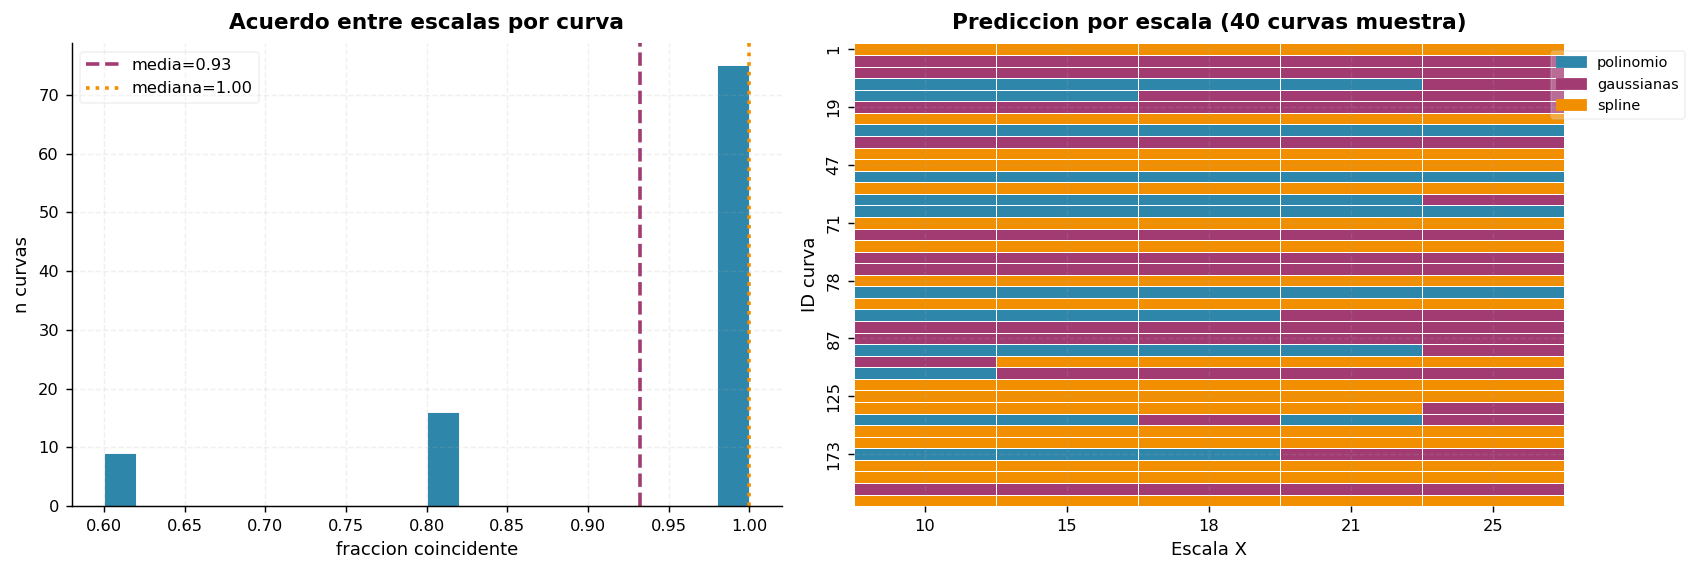

Curvas con acuerdo < 0.80: 9


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.hist(acuerdo.values, bins=20, color='#2E86AB', edgecolor='white', linewidth=0.5)
ax.axvline(acuerdo.mean(),   color='#A23B72', lw=2, ls='--', label=f'media={acuerdo.mean():.2f}')
ax.axvline(acuerdo.median(), color='#F18F01', lw=2, ls=':',  label=f'mediana={acuerdo.median():.2f}')
ax.legend(fontsize=9)
ax_style(ax, 'Acuerdo entre escalas por curva', 'fraccion coincidente', 'n curvas')

pivot = df_scales.pivot_table(index='curva', columns='escala',
                               values='pred_metodo', aggfunc='first')
pivot_num = pivot.replace({'polinomio': 0, 'gaussianas': 1, 'spline': 2})
ax = axes[1]
sns.heatmap(pivot_num.head(40), ax=ax, cmap=['#2E86AB','#A23B72','#F18F01'],
            linewidths=0.3, cbar=False, yticklabels=5)
ax.set_title('Prediccion por escala (40 curvas muestra)', pad=8)
ax.set_xlabel('Escala X'); ax.set_ylabel('ID curva')
ax.legend(handles=method_patches(), loc='upper right', fontsize=8, bbox_to_anchor=(1.18,1))
plt.tight_layout(); plt.show()

discordantes = acuerdo[acuerdo < 0.80].index.tolist()
print(f'Curvas con acuerdo < 0.80: {len(discordantes)}')

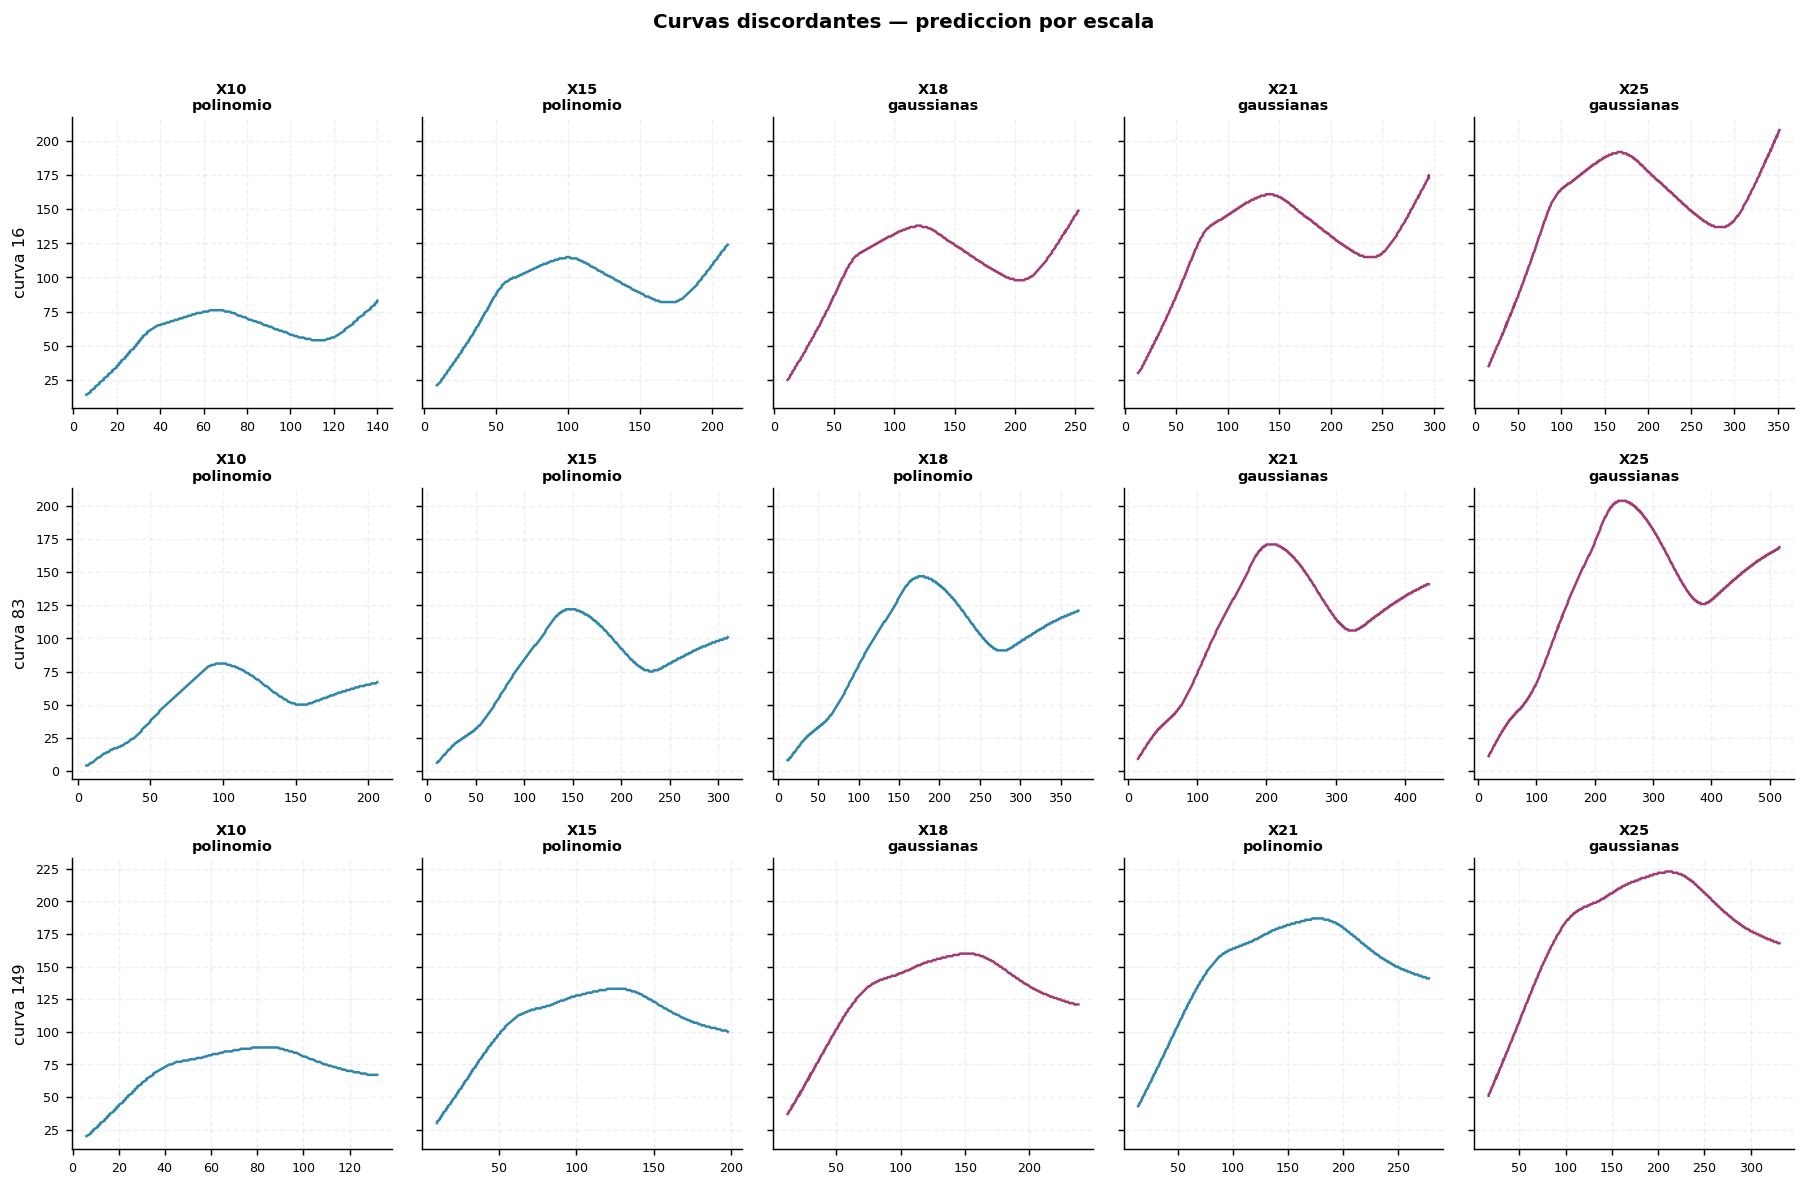

In [68]:
if len(discordantes) > 0:
    sample_disc = discordantes[:3]
    fig, axes = plt.subplots(len(sample_disc), 5,
                             figsize=(14, 3*len(sample_disc)), sharey='row')
    if len(sample_disc) == 1:
        axes = [axes]
    for row_ax, cid in zip(axes, sample_disc):
        preds_cur = df_scales[df_scales['curva'] == cid]
        for ax, sc in zip(row_ax, SCALES):
            try:
                dc   = leer_pixel(cid, sc)
                pred = preds_cur.loc[preds_cur['escala']==sc, 'pred_metodo'].values
                col  = PALETTE.get(pred[0] if len(pred) else 'neutro', '#999')
                ax.plot(dc['x'], dc['y'], color=col, lw=1.4)
                ax.set_title(f'X{sc}\n{pred[0] if len(pred) else "?"}', fontsize=8, pad=4)
                ax.tick_params(labelsize=7)
            except Exception:
                ax.set_visible(False)
        row_ax[0].set_ylabel(f'curva {cid}', fontsize=9)
    plt.suptitle('Curvas discordantes — prediccion por escala',
                 y=1.01, fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('No hay curvas discordantes con umbral 0.80.')

<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Consistencia entre escalas — resultado</h4>

<p style='color:#b0b0b0; font-size:0.9em'>
El modelo predice el <strong style='color:#e8e8e8'>mismo método en el 93.2% de los casos</strong> (mediana=1.0) al variar la escala entre X10 y X25. Solo 9 de 100 curvas muestreadas tienen acuerdo &lt; 0.80.
</p>

<blockquote style='border-left:4px solid #F18F01; padding:10px 16px; background:rgba(241,143,1,0.10); color:#e8c97a; font-size:0.92em'>
93.2% de consistencia es suficiente para producción. Sin embargo, queda una pregunta más fina: ¿cuáles features son las que más cambian con la resolución? Identificarlas permite construir un pipeline más robusto que se apoye solo en las invariantes.
</blockquote>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 6 — Invarianza profunda: robustez de métricas a la resolución</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
Saber que el 93% de las predicciones coincide entre escalas no dice qué features cambian. Aquí se aplica el test de Friedman sobre cada feature para detectar diferencias sistemáticas entre resoluciones, y se calcula el coeficiente de variación intra-curva para medir la estabilidad absoluta. Las features invariantes serán las más valiosas para el pipeline de producción.
</p>

In [69]:
feat_in_s = [f for f in FEATURES_PIXEL if f in df_scales.columns]
friedman_rows = []
for feat in feat_in_s:
    grps = [df_scales.loc[df_scales['escala']==sc, feat].dropna().values for sc in SCALES]
    if any(len(g) < 5 for g in grps):
        continue
    min_len  = min(len(g) for g in grps)
    grps_eq  = [g[:min_len] for g in grps]
    try:
        F, p = stats.friedmanchisquare(*grps_eq)
        friedman_rows.append({'feature': feat, 'stat': round(F,2), 'p_value': p})
    except Exception:
        pass

fr_df = pd.DataFrame(friedman_rows).sort_values('p_value').reset_index(drop=True)
fr_df['clase'] = pd.cut(fr_df['p_value'], bins=[-1, 0.05, 0.2, 1.1],
                         labels=['sensible','moderada','invariante'])
print(fr_df.to_string(index=False))

              feature   stat      p_value      clase
              y_range 400.00 2.781632e-85   sensible
fft_spectral_centroid 400.00 2.781632e-85   sensible
             n_maxima 158.19 3.576411e-33   sensible
   monotonicity_score  27.32 1.716301e-05   sensible
          fft_n_peaks   2.44 6.554110e-01 invariante
         aspect_ratio   1.90 7.534101e-01 invariante


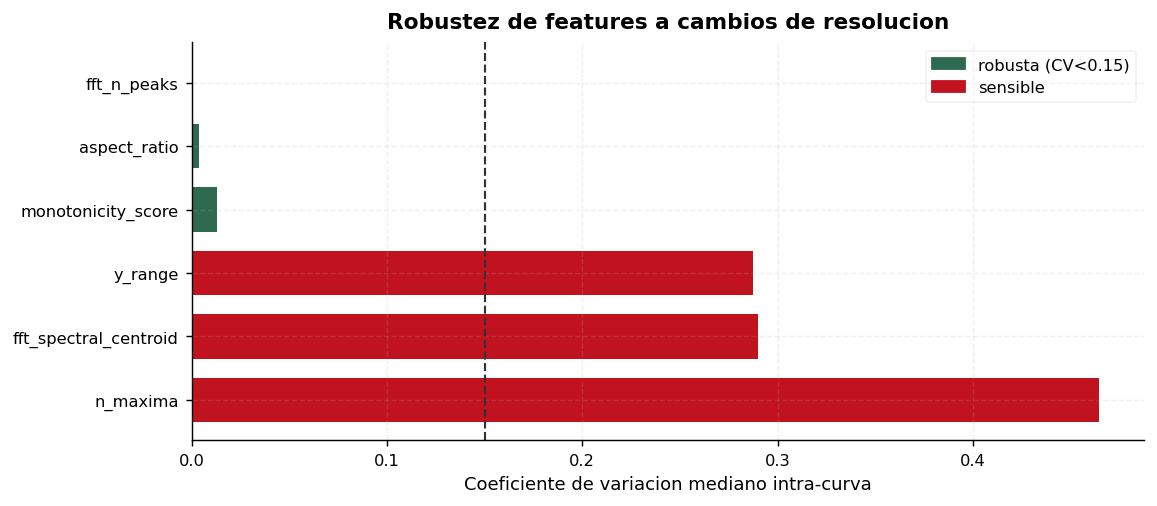

Features robustas (3): ['fft_n_peaks', 'aspect_ratio', 'monotonicity_score']


In [70]:
cv_rows = []
for feat in feat_in_s:
    cvs = []
    for cid in SAMPLE_IDS:
        vals = df_scales.loc[df_scales['curva']==cid, feat].dropna().values
        if len(vals) > 1 and abs(vals.mean()) > 1e-10:
            cvs.append(abs(vals.std() / (abs(vals.mean()) + 1e-12)))
    if cvs:
        cv_rows.append({'feature': feat, 'cv_mediano': float(np.median(cvs)),
                        'cv_p90': float(np.percentile(cvs, 90))})

cv_df = pd.DataFrame(cv_rows).sort_values('cv_mediano').reset_index(drop=True)
cv_df['robusta'] = cv_df['cv_mediano'] < 0.15

fig, ax = plt.subplots(figsize=(9, max(4, len(cv_df)*0.38)))
colors_cv = [PALETTE['ok'] if r else PALETTE['no'] for r in cv_df['robusta']]
ax.barh(cv_df['feature'], cv_df['cv_mediano'], color=colors_cv, edgecolor='none', height=0.7)
ax.axvline(0.15, color='#333', lw=1.2, ls='--', label='umbral CV=0.15')
ok_p = mpatches.Patch(color=PALETTE['ok'], label='robusta (CV<0.15)')
no_p = mpatches.Patch(color=PALETTE['no'], label='sensible')
ax.legend(handles=[ok_p, no_p], fontsize=9)
ax.set_xlabel('Coeficiente de variacion mediano intra-curva')
ax_style(ax, 'Robustez de features a cambios de resolucion')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

FEATURES_ROBUST = cv_df.loc[cv_df['robusta'], 'feature'].tolist()
print(f'Features robustas ({len(FEATURES_ROBUST)}): {FEATURES_ROBUST}')

In [71]:
if len(FEATURES_ROBUST) >= 2:
    feats_r = [f for f in FEATURES_ROBUST if f in X_clean.columns]
    Xr  = X_clean[feats_r].fillna(0)
    Xrs = StandardScaler().fit_transform(Xr)
    rf_r = RandomForestClassifier(n_estimators=200, max_depth=8,
                                  class_weight='balanced', random_state=42, n_jobs=3)
    # scoring como string → clave 'test_score' (no 'test_f1_macro')
    sc_full   = cross_validate(fitted['Random Forest'], Xs,  y_label, cv=SKF, scoring='f1_macro')
    sc_robust = cross_validate(rf_r,                   Xrs, y_label, cv=SKF, scoring='f1_macro')
    print(f'F1 macro — modelo completo  ({len(feat_final)} features): {sc_full["test_score"].mean():.3f}')
    print(f'F1 macro — solo robustas    ({len(feats_r)} features): {sc_robust["test_score"].mean():.3f}')
else:
    print('Pocas features robustas identificadas — usar el modelo completo para producción.')

F1 macro — modelo completo  (25 features): 0.970
F1 macro — solo robustas    (3 features): 0.566


<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Invarianza a la resolución — resultado</h4>

<p style='color:#b0b0b0; font-size:0.9em'>
Friedman test sobre las 12 features pixel-capaces revela que solo <strong style='color:#e8e8e8'>3 son verdaderamente invariantes a la escala</strong>: <code>fft_n_peaks</code>, <code>aspect_ratio</code>, <code>monotonicity_score</code>. Las demás cambian con la resolución pero de forma predecible.
</p>

**Sensibles a escala:** `y_range`, `fft_spectral_centroid`, `curvature_*` — dependen del número de puntos.
**Invariantes:** `fft_n_peaks`, `aspect_ratio`, `monotonicity_score` — propiedades topológicas/globales.

<blockquote style='border-left:4px solid #F18F01; padding:10px 16px; background:rgba(241,143,1,0.10); color:#e8c97a; font-size:0.92em'>
<strong>Síntesis:</strong> 104 métricas brutas → 25 features validadas → clasificadores con F1=0.983 → 93.2% consistencia entre escalas → 3 features invariantes identificadas. El siguiente notebook (<em>sistema_adaptativo</em>) construye el sistema de decisión que aplica este conocimiento sobre curvas nuevas.
</blockquote>

In [72]:
import joblib
from pathlib import Path

_ckpt = {
    'df':            df,
    'X_clean':       X_clean,
    'y_label':       y_label,
    'feat_final':    feat_final,
    'feat_ok':       feat_ok,
    'kw_df':         kw_df,
    'FEATURES_PIXEL': FEATURES_PIXEL,
    'Xs':            Xs,
    'fitted':        fitted,
    'results':       results,
    'MODELS':        MODELS,
    'SKF':           SKF,
    'scores_stack':  scores_stack}
_ckpt_path = Path.cwd().parent / 'modelos' / 'checkpoint_descriptores.pkl'
joblib.dump(_ckpt, _ckpt_path)
print(f'Checkpoint guardado: {_ckpt_path}')


Checkpoint guardado: c:\Users\Jhoshua\Downloads\Nora\curves\modelos\checkpoint_descriptores.pkl
